<a href="https://colab.research.google.com/github/SrarifaRania/BioSym_Test/blob/main/BioSym_train219_val99_2obj_of_GP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

import pandas as pd
import operator
import numpy as np
from sklearn.metrics import r2_score
import random
import copy
import math
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive')

file_path = "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_dataset.csv"
df = pd.read_csv(file_path)


FEATURE_COLUMNS = ['Soil', 'Slope', 'Rain', 'LULC', 'Lithology','Lineament density', 'Geomorphology', 'Drainage density']
# #FEATURE_COLUMNS = ['geomorphology','Rain','drainage density']
TARGET_COLUMN = 'Net Groundwater Recharge'

X = df[FEATURE_COLUMNS].values
y = df[TARGET_COLUMN].values
validation_labels = df['validation point categorical data'].values



# Filter dataframe to use selected features
#df_filtered = df[FEATURE_COLUMNS + [TARGET_COLUMN]].copy()

# Optional: filter out extreme target values (e.g., outliers above 300)
#df_filtered = df_filtered[df_filtered[TARGET_COLUMN] < 300]

# Extract X and y
#X = df_filtered[FEATURE_COLUMNS].values
#y = df_filtered[TARGET_COLUMN].values

#Inspect shapes and first few rows
#print("Shape of X:", X.shape)
#print("Shape of y:", y.shape)
#print("Sample features (X):", X[:3])
#print("Sample target values (y):", y[:3])

# Mapping: x0 -> 'Soil', x1 -> 'Slope', etc.
symbolic_variable_map = {f'x{i}': FEATURE_COLUMNS[i] for i in range(len(FEATURE_COLUMNS))}

print("Symbolic Variable Mapping:")
for symbol, name in symbolic_variable_map.items():
     print(f"{symbol} → {name}")

Mounted at /content/drive
Symbolic Variable Mapping:
x0 → Soil
x1 → Slope
x2 → Rain
x3 → LULC
x4 → Lithology
x5 → Lineament density
x6 → Geomorphology
x7 → Drainage density


In [ ]:
#### Train "GW_potential_8Indicator_318pointsData.xls"

# drive.mount('/content/drive')
# file_path = "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/GW_potential_8Indicator_318pointsData.xls"

# df = pd.read_excel(file_path)
# #df.head()

# print(df.columns.tolist())


# FEATURE_COLUMNS = ['LULC', 'drainage density', 'geomorphology', 'Soil', 'Slope', 'Raninfall', 'Lithology', 'lineament density']
# TARGET_COLUMN = 'validation point raw data'

# X = df[FEATURE_COLUMNS].values
# y = df[TARGET_COLUMN].values

# # # Mapping: x0 -> 'Soil', x1 -> 'Slope', etc.
# symbolic_variable_map = {f'x{i}': FEATURE_COLUMNS[i] for i in range(len(FEATURE_COLUMNS))}

# print("Symbolic Variable Mapping:")
# for symbol, name in symbolic_variable_map.items():
#      print(f"{symbol} → {name}")

In [ ]:
# #### Linear regression
# """
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# model = LinearRegression().fit(X, y)
# pred = model.predict(X)
# print("R² (Linear):", r2_score(y, pred))
# """

In [ ]:
def clamp(v, lo, hi):
    return max(lo, min(hi, v))

def safe_exp(x):
    # Prevent overflow
    return math.exp(clamp(x, -20, 20))

def safe_pow(x, y):
    # Prevent extreme exponents and huge bases
    base = abs(x) + 1e-6
    expn = clamp(y, -3, 3)
    return math.pow(base, expn)

# Protected division to avoid divide-by-zero
def protected_div(x, y):
    try:
        return x / y if abs(y) > 1e-6 else 1.0
    except:
        return 1.0

OPERATORS = {
    '+': (operator.add, 2),
    '-': (operator.sub, 2),
    '*': (operator.mul, 2),
    '/': (protected_div, 2),
    'neg': (lambda x: -x, 1),
    'sin': (math.sin, 1),
    'cos': (math.cos, 1),
    #'exp': (math.exp, 1),
    'log': (lambda x: math.log(abs(x) + 1e-6), 1),  # protected log
    'square': (lambda x: x * x, 1),
    'cube': (lambda x: x * x * x, 1),
    'exp': (safe_exp, 1),
    'pow': (safe_pow, 2),
}

class Node:
    def __init__(self, name, children=None):
        self.name = name
        self.children = children if children else []

    def evaluate(self, X_row, feature_map=None):
        if self.name in OPERATORS:
            func, arity = OPERATORS[self.name]
            if len(self.children) != arity:
                raise ValueError(f"Invalid expression: Operator '{self.name}' expects {arity} children, got {len(self.children)}")
            args = [child.evaluate(X_row, feature_map) for child in self.children]
            return func(*args)
        elif feature_map and self.name in feature_map:
            return X_row[feature_map[self.name]]
        elif isinstance(self.name, str) and self.name.startswith('x'):
            idx = int(self.name[1:])
            return X_row[idx]
        else:
            return float(self.name)

    # def count_nodes(self):
    #     return 1 + sum(child.count_nodes() for child in self.children)

    def to_string(self, feature_names=None):
        if self.name in OPERATORS:
            return f"{self.name}({', '.join(child.to_string(feature_names) for child in self.children)})"
        elif isinstance(self.name, str) and self.name.startswith('x') and feature_names:
            idx = int(self.name[1:])
            return feature_names[idx]
        else:
            return str(self.name)

    def __str__(self):
        return self.to_string()

    def weighted_complexity(self, parent_is_nonlinear=False, depth=1):
        LINEAR_OPS = {'+', '-', 'neg'}
        MILD_NONLINEAR_OPS = {'*'}
        STRONG_NONLINEAR_OPS = {'/', 'log', 'exp', 'pow', 'sin', 'cos', 'square', 'cube'}

        #feature=0
        if isinstance(self.name, str) and self.name.startswith('x'):
            cost = 0
            is_nonlinear = False
        elif self.name in LINEAR_OPS:
            cost = 1
            is_nonlinear = False
        elif self.name in MILD_NONLINEAR_OPS:
            cost = 1.25
            is_nonlinear = False
        elif self.name in STRONG_NONLINEAR_OPS:
            if self.name == '/':
                cost = 1.5
            elif self.name in ['square', 'cube']:
                cost = 1.5 if self.name == 'square' else 2
            elif self.name in ['sin', 'cos', 'log', 'exp']:
                cost = 1.25
            else:  # pow
                cost = 2
            is_nonlinear = True
        elif is_constant(self.name):
            cost = 0.5
            is_nonlinear = False
        else:
            cost = 1
            is_nonlinear = False

        # 2. Penalize ONLY problematic cases:
        # Very deep trees (>15 levels)
        depth_penalty = 0.1 * max(0, depth - 15)  # Applies to ALL nodes

        # Redundant nesting (sin(cos)), but not single nonlinear terms
        recursive_penalty = 0.05 if (parent_is_nonlinear and self.name in STRONG_NONLINEAR_OPS) else 0

        total = cost + depth_penalty + recursive_penalty
        for child in self.children:
            total += child.weighted_complexity(self.name in STRONG_NONLINEAR_OPS, depth + 1)
        return total

def is_constant(name):
    #Check if node is a numeric constant (handles negatives and floats)
    if isinstance(name, (int, float)):
        return True
    try:
        float(name)
        return True
    except (ValueError, TypeError):
        return False

def to_readable_string(self, var_map):
    if self.name in OPERATORS:
        return f"{self.name}({', '.join(child.to_readable_string(var_map) for child in self.children)})"
    else:
        return var_map.get(self.name, str(self.name))

Node.to_readable_string = to_readable_string

In [ ]:
def generate_random_tree(max_depth, feature_count, current_depth=0, parent_op=None):
    # Make deeper trees more likely
    terminal_prob = 0.1 + 0.4 * (current_depth / max_depth) ## (more terminals → smaller trees)

    if current_depth >= max_depth or random.random() < terminal_prob:
        # Prefer features (70%) over constants (30%)
        if random.random() < 0.7:
            return Node(f'x{random.randint(0, feature_count - 1)}')
        else:
            return Node(str(round(random.uniform(-5, 5), 2)))
    else:
        # Add operator variety
        op_weights = {
            '+': 0.18, '-': 0.18, '*': 0.20, '/': 0.07,
            'sin': 0.06, 'cos': 0.06,
            'log': 0.06, 'exp': 0.04,
            'square': 0.06, 'cube': 0.03,
            'pow': 0.06
        }

        op = random.choices(list(op_weights.keys()), weights=list(op_weights.values()), k=1)[0]
        func, arity = OPERATORS[op]
        children = [generate_random_tree(max_depth, feature_count, current_depth + 1, op) for _ in range(arity)]
        return Node(op, children)


In [ ]:
# Recursively collect all nodes along with their parent nodes
def collect_nodes_with_parents(node, parent=None):
    nodes = [(node, parent)]
    for child in node.children:
        nodes.extend(collect_nodes_with_parents(child, node))
    return nodes

## Crossover
def crossover(tree1, tree2):
    child1 = copy.deepcopy(tree1)
    child2 = copy.deepcopy(tree2)

    # Collect all nodes with their parent references
    nodes1 = collect_nodes_with_parents(child1)
    nodes2 = collect_nodes_with_parents(child2)

    # Prefer internal nodes (i.e., operators), fallback to any node
    op_nodes1 = [n for n in nodes1 if n[0].name in OPERATORS]
    op_nodes2 = [n for n in nodes2 if n[0].name in OPERATORS]

    if op_nodes1 and op_nodes2:
        (target1, parent1), (target2, parent2) = random.choice(op_nodes1), random.choice(op_nodes2)
    else:
        (target1, parent1), (target2, parent2) = random.choice(nodes1), random.choice(nodes2)

    # Swap the subtrees
    if parent1 is None:
        child1 = target2
    else:
        idx = parent1.children.index(target1)
        parent1.children[idx] = target2

    if parent2 is None:
        child2 = target1
    else:
        idx = parent2.children.index(target2)
        parent2.children[idx] = target1

    # print crossover to check
    # print(f"[CROSSOVER] Parent1: {tree1.to_string()}")
    # print(f"[CROSSOVER] Parent2: {tree2.to_string()}")
    # print(f"[CROSSOVER] Child1 : {child1.to_string()}")
    # print(f"[CROSSOVER] Child2 : {child2.to_string()}")

    return child1, child2


# # # Mutation
def mutate(tree, max_depth, feature_count):
    tree_copy = copy.deepcopy(tree)
    nodes = collect_nodes_with_parents(tree_copy)
    target_node, parent = random.choice(nodes)

    mutation_type = random.choice(['subtree', 'operator', 'constant', 'feature'])

    if mutation_type == 'subtree':
        new_subtree = generate_random_tree(max_depth=max_depth, feature_count=feature_count)
        if parent is None:
            return new_subtree
        else:
            idx = parent.children.index(target_node)
            parent.children[idx] = new_subtree

    elif mutation_type == 'operator' and target_node.name in OPERATORS:
        current_op = target_node.name
        valid_ops = [op for op in OPERATORS if OPERATORS[op][1] == OPERATORS[current_op][1] and op != current_op]
        if valid_ops:
            new_op = random.choice(valid_ops)
            target_node.name = new_op

    elif mutation_type == 'constant' and is_constant(target_node.name):
        new_val = round(random.uniform(-10, 10), 2)
        target_node.name = new_val

    elif mutation_type == 'feature' and isinstance(target_node.name, str) and target_node.name.startswith('x'):
        old_feature = target_node.name
        new_feature = old_feature
        while new_feature == old_feature:
            new_feature = f'x{random.randint(0, feature_count - 1)}'
        target_node.name = new_feature
        #print(f"[MUTATION] Replaced feature {old_feature} → {new_feature}")

    return tree_copy



In [ ]:
class Individual:
    def __init__(self, tree, X, y, feature_names, validation_labels=None):
        self.tree = tree
        self.X = X
        self.y = y
        self.feature_names = feature_names
        self.validation_labels = validation_labels

        self.rank = None
        self.crowding_distance = 0.0

        self._evaluate()
        #print(f"[Debug] Feature names: {self.feature_names}")


    def _evaluate(self):
        try:
            # Evaluate predictions
            y_pred = np.clip([self.tree.evaluate(row) for row in self.X], -1e3, 1e3)
            self.r2 = r2_score(self.y, y_pred)
            self.predicted = y_pred
        except Exception:
            self.r2 = -np.inf
            self.predicted = [None] * len(self.y)

        # complexity calculation
        #self.complexity = self.tree.count_nodes()
        self.complexity = self.tree.weighted_complexity()

        # Spearman rank correlation (if validation labels exist)
        if self.validation_labels is not None and self.predicted is not None:
            try:
                predictions = np.array(self.predicted)
                dfq = pd.DataFrame({'predictions': predictions})
                unique_values = np.unique(predictions)

                if len(unique_values) > 5:
                    try:
                        dfq['predicted_class'] = pd.cut(dfq['predictions'], 5, labels=[1, 2, 3, 4, 5])
                    except ValueError:
                        dfq['predicted_class'] = 3  # fallback
                else:
                    dfq['predicted_class'] = 3  # fallback

                dfq['target_class'] = self.validation_labels

                predicted_classes = dfq['predicted_class'].to_numpy()
                target_classes = dfq['target_class'].to_numpy()

                if np.all(predicted_classes == predicted_classes[0]):
                    self.spearman_corr, self.spearman_p = 0.0, 1.0
                else:
                    corr, pval = spearmanr(predicted_classes, target_classes)
                    self.spearman_corr = 0.0 if np.isnan(corr) else corr
                    self.spearman_p = pval

            except Exception as e:
                print(f"[Spearman Error] {e}")
                self.spearman_corr = None
                self.spearman_p = None
        else:
            self.spearman_corr = None
            self.spearman_p = None


    @property
    def fitness(self):
        return [-self.r2, self.complexity] #-r2= maximize r2

    @property
    def symbolic(self):
        return str(self.tree)

    @property
    def readable(self):
        return self.tree.to_readable_string(self.feature_names)


    def copy(self):
        return Individual(copy.deepcopy(self.tree), self.X, self.y, self.feature_names, self.validation_labels)

    # def score(self, alpha=1.0, beta=0.01):
    #     return alpha * self.r2 - beta * self.complexity


In [ ]:
# Check if one individual dominates another
def dominates(ind_a, ind_b):
    f1_a, f2_a = ind_a.fitness
    f1_b, f2_b = ind_b.fitness
    return (f1_a <= f1_b and f2_a <= f2_b) and (f1_a < f1_b or f2_a < f2_b)

# Non-dominated sort to identify Pareto fronts
def non_dominated_sort(population):
    fronts = []
    dominated_count = {}
    dominates_list = {}
    individuals = list(range(len(population)))

    for p in individuals:
        dominated_count[p] = 0
        dominates_list[p] = []
        for q in individuals:
            if p == q:
                continue
            if dominates(population[p], population[q]):
                dominates_list[p].append(q)
            elif dominates(population[q], population[p]):
                dominated_count[p] += 1
        if dominated_count[p] == 0:
            if len(fronts) == 0:
                fronts.append([])
            fronts[0].append(p)

    i = 0
    while i < len(fronts) and len(fronts[i]) > 0:
        next_front = []
        for p in fronts[i]:
            for q in dominates_list[p]:
                dominated_count[q] -= 1
                if dominated_count[q] == 0:
                    next_front.append(q)
        i += 1
        if next_front:
            fronts.append(next_front)

    return fronts


In [ ]:
# NSGA-II survivor selection using non-dominated sorting and crowding distance

def objective_value(ind, obj):
    if obj == 'r2':
        return -ind.r2   # convert R² to minimization
    elif obj == 'complexity':
        return ind.complexity
    else:
        return getattr(ind, obj)


def compute_crowding_distance(front, objectives):
    size = len(front)
    if size == 0:
        return {}

    distance = {ind: 0.0 for ind in front}

    for obj in objectives:
        sorted_front = sorted(front, key=lambda ind: objective_value(ind, obj))

        distance[sorted_front[0]] = float('inf')
        distance[sorted_front[-1]] = float('inf')

        obj_min = objective_value(sorted_front[0], obj)
        obj_max = objective_value(sorted_front[-1], obj)

        if obj_max == obj_min:
            continue

        for j in range(1, size - 1):
            prev_val = objective_value(sorted_front[j - 1], obj)
            next_val = objective_value(sorted_front[j + 1], obj)

            distance[sorted_front[j]] += (next_val - prev_val) / (obj_max - obj_min)

    return distance

def select_survivors(population, num_survivors):
    fronts = non_dominated_sort(population)
    survivors = []
    objectives = ['r2', 'complexity']  # used for crowding distance

    for front_indices in fronts:
        front = [population[i] for i in front_indices]
        if len(survivors) + len(front) <= num_survivors:
            survivors.extend(front)
        else:
            distances = compute_crowding_distance(front, objectives)
            sorted_front = sorted(front, key=lambda ind: -distances[ind])
            survivors.extend(sorted_front[:num_survivors - len(survivors)])
            break

    return survivors



## Assign NSGA-II rank and crowding_distance to individuals in `population`

def assign_rank_and_crowding(population, objectives=('r2', 'complexity')):

    fronts = non_dominated_sort(population)

    # set defaults
    for ind in population:
        ind.rank = float('inf')
        ind.crowding_distance = 0.0

    for rank, front_indices in enumerate(fronts):
        front = [population[i] for i in front_indices]

        # assign rank
        for ind in front:
            ind.rank = rank

        # assign crowding distance
        distances = compute_crowding_distance(front, list(objectives))
        for ind in front:
            ind.crowding_distance = distances.get(ind, 0.0)


## lower rank wins and if rank tie -> higher crowding_distance wins

def crowded_tournament_selection(population, k):
    selected = []
    for _ in range(k):
        a, b = random.sample(population, 2)

        if a.rank < b.rank:
            selected.append(a)
        elif b.rank < a.rank:
            selected.append(b)
        else:
            # same rank -> prefer higher crowding distance
            if a.crowding_distance > b.crowding_distance:
                selected.append(a)
            elif b.crowding_distance > a.crowding_distance:
                selected.append(b)
            else:
                selected.append(a if random.random() < 0.5 else b)

    return selected

In [ ]:
def generate_offspring(parents, num_offspring, max_depth, feature_count, mutation_rate=0.7):
    offspring = []
    while len(offspring) < num_offspring:
        p1, p2 = random.sample(parents, 2)

        # Crossover
        child1_tree, child2_tree = crossover(p1.tree, p2.tree)
        print(f"[CROSSOVER] Parent1: {p1.tree.to_string()}")
        print(f"[CROSSOVER] Parent2: {p2.tree.to_string()}")
        print(f"[CROSSOVER] Child1 : {child1_tree.to_string()}")
        print(f"[CROSSOVER] Child2 : {child2_tree.to_string()}")

        child1 = Individual(child1_tree, p1.X, p1.y, p1.feature_names)
        child2 = Individual(child2_tree, p2.X, p2.y, p2.feature_names)

        # Mutation for Child1
        if random.random() < mutation_rate:
            if random.random() < 0.05: # only 5% chance of full reset
                new_tree = generate_random_tree(max_depth, feature_count)
                print(f"[MUTATION] Child1 replaced by new random tree: {new_tree.to_string()}")
                child1 = Individual(new_tree, p1.X, p1.y, p1.feature_names)
            else:
                print(f"[MUTATION] Before mutation (Child1): {child1.tree.to_string()}")
                mutated_tree = mutate(child1.tree, max_depth, feature_count)
                print(f"[MUTATION] After mutation  (Child1): {mutated_tree.to_string()}")
                child1 = Individual(mutated_tree, p1.X, p1.y, p1.feature_names)

        # Mutation for Child2
        if random.random() < mutation_rate:
            if random.random() < 0.05:  # only 5% chance of full reset
                new_tree = generate_random_tree(max_depth, feature_count)
                print(f"[MUTATION] Child2 replaced by new random tree: {new_tree.to_string()}")
                child2 = Individual(new_tree, p2.X, p2.y, p2.feature_names)
            else:
                print(f"[MUTATION] Before mutation (Child2): {child2.tree.to_string()}")
                mutated_tree = mutate(child2.tree, max_depth, feature_count)
                print(f"[MUTATION] After mutation  (Child2): {mutated_tree.to_string()}")
                child2 = Individual(mutated_tree, p2.X, p2.y, p2.feature_names)

        offspring.append(child1)
        if len(offspring) < num_offspring:
            offspring.append(child2)

    return offspring[:num_offspring]


In [ ]:
## pareto front method

def get_pareto_front(population):
    """Pareto front using fitness = [-r2, complexity]."""
    pareto = []

    for i, ind in enumerate(population):
        dominated = False

        for j, other in enumerate(population):
            if i == j:
                continue

            if (
                other.fitness[0] <= ind.fitness[0] and
                other.fitness[1] <= ind.fitness[1] and
                (
                    other.fitness[0] < ind.fitness[0] or
                    other.fitness[1] < ind.fitness[1]
                )
            ):
                dominated = True
                break

        if not dominated:
            pareto.append(ind)

    return pareto

###TEST #####.   feature track per generation
from collections import Counter

feature_usage_log = []  # Global tracker


def count_features(tree):
    if isinstance(tree.name, str) and tree.name.startswith('x'):
        return Counter([tree.name])
    counts = Counter()
    for child in tree.children:
        counts += count_features(child)
    return counts


In [ ]:
all_logs = []


In [ ]:
def create_individual_population(n_individuals, max_depth, feature_count, X, y, feature_names):
    population = []
    for _ in range(n_individuals):
        tree = generate_random_tree(max_depth=max_depth, feature_count=feature_count)
        ind = Individual(tree, X, y, feature_names)
        population.append(ind)
    return population

#all_logs = []

def run_gp_evolution(
    X, y, feature_names,
    population_size=50, #default value
    generations=100,  #default value
    max_depth=4,  #default value
    mutation_rate=.2  #default value
):
    #Initial population
    population = create_individual_population(
        n_individuals=population_size,
        max_depth=max_depth,
        feature_count=len(feature_names),
        X=X,
        y=y,
        feature_names=feature_names
    )

    global_archive_map = {}
    gen_expr_log_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_all_generation_expressions_log.txt'
    gen_expr_log = open(gen_expr_log_path, 'w')


    #feature_usage_log = []  # TEST global tracker for features track in all generations

    for gen in range(generations):
        #print(f"\nGeneration {gen + 1}/{generations}")

        assign_rank_and_crowding(population, objectives=('r2', 'complexity'))

        parents = crowded_tournament_selection(population, k=population_size)

        offspring = generate_offspring(
            parents=parents,
            num_offspring=population_size,
            max_depth=max_depth,
            feature_count=len(feature_names),
            mutation_rate=mutation_rate
        )

        combined_population = population + offspring

        population = select_survivors(
            combined_population,
            num_survivors=population_size
        )

        # Optional diversity injection every 10 generations
        if gen % 10 == 0:
            num_random = 5
            random_inds = create_individual_population(
                n_individuals=num_random,
                max_depth=max_depth,
                feature_count=len(feature_names),
                X=X,
                y=y,
                feature_names=feature_names
            )

            population = select_survivors(
                population + random_inds,
                num_survivors=population_size
            )

        gen_front = get_pareto_front(population)

        for ind in gen_front:
            key = ind.symbolic
            if key not in global_archive_map or ind.r2 > global_archive_map[key].r2:
                global_archive_map[key] = ind


        gen_header = f"\nGeneration {gen + 1}"
        print(gen_header)
        gen_expr_log.write(gen_header + '\n')

        for i, ind in enumerate(population):
            expr_line = f"Individual {i + 1}, R²: {ind.r2:.4f}, Complexity: {ind.complexity:.4f}, Expr: {ind.readable}"
            print(expr_line)
            gen_expr_log.write(expr_line + '\n')

        ### test features over generation
        # Collect feature usage for this generation
        generation_usage = Counter()
        for ind in population:
            generation_usage += count_features(ind.tree)
        feature_usage_log.append(generation_usage)


### for all log in excel
        for i, ind in enumerate(population):
            try:
                y_pred = [ind.tree.evaluate(row) for row in ind.X]
            except Exception:
                y_pred = [None] * len(ind.y)

            # Convert to comma-separated strings
            target_str = ",".join([f"{v:.4f}" for v in ind.y])
            pred_str = ",".join([f"{v:.4f}" if v is not None else "NaN" for v in y_pred])

            all_logs.append({
                "Generation": gen+1,
                "Individual": i,
                "R2": ind.r2,
                "Complexity": ind.complexity,
                "Targets": target_str,
                "Predictions": pred_str,
                #"Expression": ind.readable  # Optional but useful
            })




    # Global Pareto front from all generations
    global_pareto = get_pareto_front(list(global_archive_map.values()))

    print("\n--- All-Generations Global Pareto Front ---")
    for ind in global_pareto:
        print(f"R²: {ind.r2:.4f}, Complexity: {ind.complexity:.4f}, Expr: {ind.readable}")

    gen_expr_log.close()
    return population  # Final evolved population
    #return population, feature_usage_log  # Adding feature log



In [ ]:
# =========================
# SINGLE-RUN
# =========================




# final_pop = run_gp_evolution(
#     X=X,
#     y=y,
#     feature_names=symbolic_variable_map,
#     population_size=160, ##100
#     generations=100,
#     max_depth=6,           # 4
#     mutation_rate=0.3      # 0.7/0.2
# )


# log_df = pd.DataFrame(all_logs)
# log_df.to_excel("/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_2obj_full_run_log.xlsx", index=False)



Streaming output truncated to the last 5000 lines.
Individual 25, R²: 0.5811, Complexity: 7.7500, Expr: *(lithology, log(-(lithology, *(+(Rain, +(lithology, geomorphology)), +(lithology, geomorphology)))))
Individual 26, R²: -1.6699, Complexity: 0.0000, Expr: LULC
Individual 27, R²: -0.7649, Complexity: 1.0000, Expr: +(geomorphology, LULC)
Individual 28, R²: -0.7649, Complexity: 1.0000, Expr: +(LULC, geomorphology)
Individual 29, R²: -0.2992, Complexity: 1.2500, Expr: *(LULC, LULC)
Individual 30, R²: 0.4831, Complexity: 2.2500, Expr: *(lithology, +(drainage density, LULC))
Individual 31, R²: 0.4947, Complexity: 6.0000, Expr: *(LULC, +(lithology, /(geomorphology, *(lithology, -(LULC, drainage density)))))
Individual 32, R²: 0.4906, Complexity: 4.7500, Expr: *(LULC, +(lithology, /(drainage density, +(LULC, Rain))))
Individual 33, R²: 0.5889, Complexity: 10.7500, Expr: *(lithology, log(-(+(Rain, -(LULC, -(lithology, geomorphology))), *(+(Rain, -(lithology, Slope)), +(geomorphology, geomor

In [ ]:
# print("Generations in all_logs:", sorted(set(entry["Generation"] for entry in all_logs)))
# print(len(all_logs))  # should be > 0
# print(all_logs[-1])   # show last log entry to confirm structure

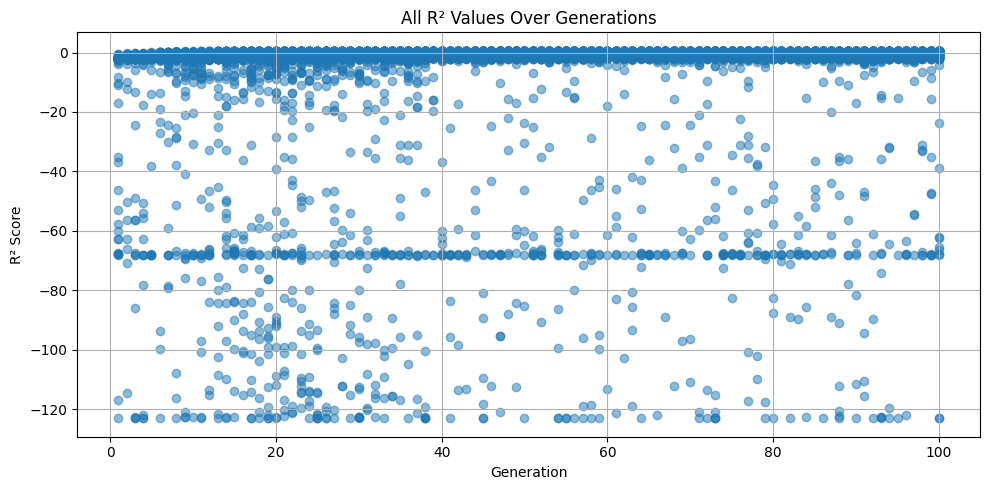

In [ ]:
# #plot R2 per genertation

import matplotlib.pyplot as plt

gen_list = []
r2_list = []

for entry in all_logs:
    generation = entry["Generation"]
    r2 = entry["R2"]
    if isinstance(r2, (int, float)):
        gen_list.append(generation)
        r2_list.append(r2)


plt.figure(figsize=(10, 5))
plt.scatter(gen_list, r2_list, alpha=0.5)
plt.xlabel("Generation")
plt.ylabel("R² Score")
plt.title("All R² Values Over Generations")
plt.grid(True)
plt.tight_layout()
plt.show()


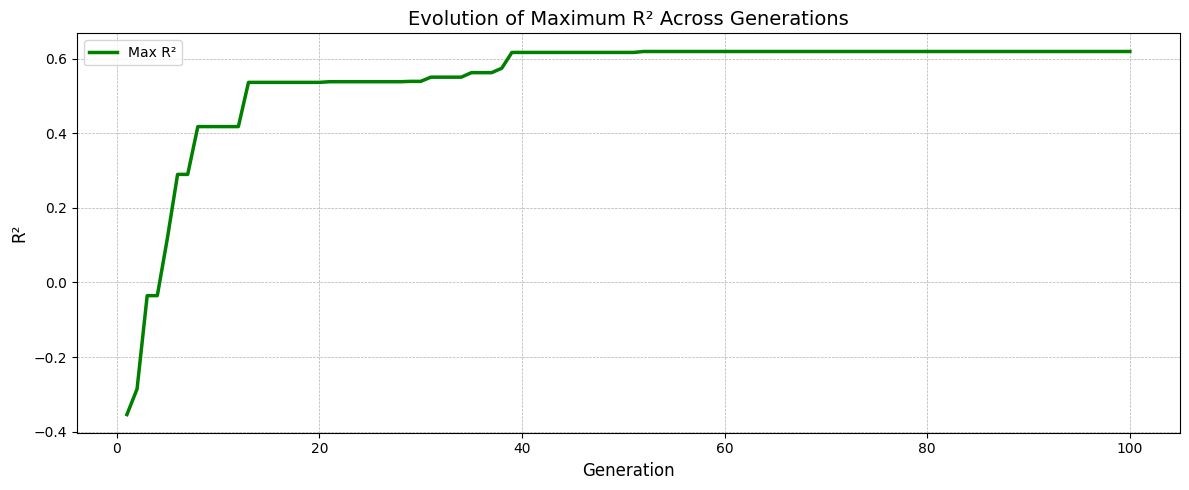

In [ ]:
# #plot max R2 per genertation

from collections import defaultdict
import pandas as pd
import matplotlib.pyplot as plt


r2_by_gen = defaultdict(list)
for entry in all_logs:
    if isinstance(entry["R2"], (int, float)) and not pd.isna(entry["R2"]):
        r2_by_gen[entry["Generation"]].append(entry["R2"])


#avg_r2_per_gen = {}
max_r2_per_gen = {}

for gen, vals in r2_by_gen.items():
    if vals:
        #avg_r2_per_gen[gen] = sum(vals) / len(vals)
        max_r2_per_gen[gen] = max(vals)


#avg_series = pd.Series(avg_r2_per_gen).sort_index()
max_series = pd.Series(max_r2_per_gen).sort_index()


plt.figure(figsize=(12, 5))
#plt.plot(avg_series.index, avg_series.values, label="Average R²", color='blue')
plt.plot(max_series.index, max_series.values, label="Max R²", color='green', linewidth=2.5)
plt.xlabel("Generation", fontsize=12)
plt.ylabel("R²", fontsize=12)
plt.title("Evolution of Maximum R² Across Generations", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()


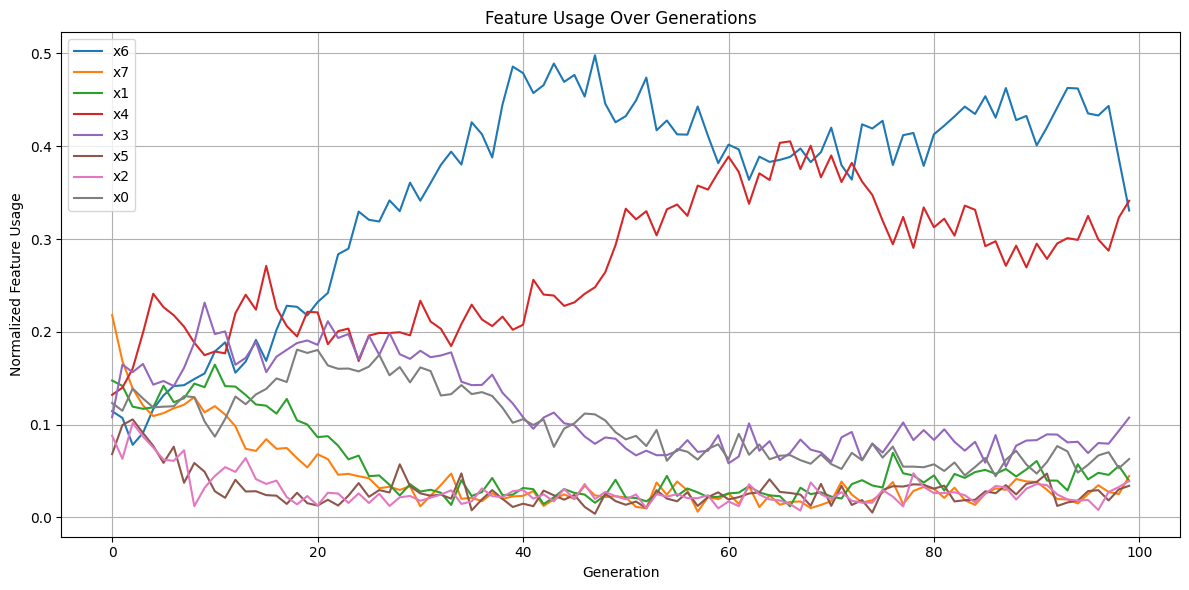

Symbolic Variable Mapping:
x0 → Soil
x1 → Slope
x2 → Rain
x3 → LULC
x4 → lithology
x5 → lineament density
x6 → geomorphology
x7 → drainage density


In [ ]:
##### TEST. Track features over generation. ###

import pandas as pd
import matplotlib.pyplot as plt

# Convert to DataFrame
usage_df = pd.DataFrame(feature_usage_log).fillna(0)

# Normalize per generation
usage_df_norm = usage_df.div(usage_df.sum(axis=1), axis=0)

# Plot
plt.figure(figsize=(12, 6))
for column in usage_df_norm.columns:
    plt.plot(usage_df_norm[column], label=column)

plt.xlabel("Generation")
plt.ylabel("Normalized Feature Usage")
plt.title("Feature Usage Over Generations")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Symbolic Variable Mapping:")
for symbol, name in symbolic_variable_map.items():
     print(f"{symbol} → {name}")

In [ ]:
## pareto font (final generation)

pareto_front = get_pareto_front(final_pop)

print("\nPareto Front:")

# path
pareto_output_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_pareto_front.txt'

# txt file writing
with open(pareto_output_path, 'w') as f:
    f.write("Pareto Front:\n")
    for ind in pareto_front:
        line = f"R²: {ind.r2:.4f}, Complexity: {ind.complexity:.4f}, Expr: {ind.readable}\n"
        print(line.strip())
        f.write(line)




Pareto Front:
R²: -1.0440, Complexity: 0.0000, Expr: geomorphology
R²: 0.4906, Complexity: 1.2500, Expr: *(LULC, lithology)
R²: -0.3132, Complexity: 1.0000, Expr: +(geomorphology, geomorphology)
R²: 0.4906, Complexity: 1.2500, Expr: *(lithology, LULC)
R²: 0.4975, Complexity: 2.2500, Expr: *(lithology, -(LULC, drainage density))
R²: 0.5971, Complexity: 11.5000, Expr: *(lithology, log(-(+(geomorphology, geomorphology), *(+(Rain, *(-4.17, +(lineament density, Rain))), -(-(lithology, Soil), geomorphology)))))
R²: 0.5896, Complexity: 10.0000, Expr: *(lithology, log(-(+(Rain, +(lineament density, Rain)), *(+(Rain, *(Soil, geomorphology)), +(geomorphology, geomorphology)))))
R²: 0.5890, Complexity: 7.7500, Expr: *(lithology, log(-(+(lineament density, Rain), *(+(Rain, Soil), +(geomorphology, geomorphology)))))
R²: 0.5973, Complexity: 14.0500, Expr: *(lithology, log(-(+(Rain, Soil), *(+(Rain, *(-4.17, +(lineament density, Rain))), -(-(lithology, Soil), exp(log(geomorphology)))))))
R²: 0.5894,

In [ ]:
## Remove duplicate Pareto solutions based on R² and Complexity

def remove_duplicate_pareto(front):

    unique = []
    seen = set()

    for ind in front:
        key = (ind.r2, ind.complexity)

        if key not in seen:
            seen.add(key)
            unique.append(ind)

    return unique

pareto = get_pareto_front(final_pop)


pareto_unique = remove_duplicate_pareto(pareto)

print("\nPareto Front (Duplicates Removed):")
for ind in pareto_unique:
    expr = ind.tree.to_readable_string(symbolic_variable_map)
    print(f"R²: {ind.r2:.4f}, Complexity: {ind.complexity:.4f}, Expr: {expr}")

txt_path = "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/pareto_front_without_duplicates.txt"

with open(txt_path, "w", encoding="utf-8") as f:
    f.write("Pareto Front (Duplicates Removed)\n\n")

    for ind in pareto_unique:
        expr = ind.tree.to_readable_string(symbolic_variable_map)
        f.write(
            f"R²: {ind.r2:.6f}, "
            f"Complexity: {ind.complexity:.6f}, "
            f"Expr: {expr}\n"
        )

print(f"\nPareto front saved to: {txt_path}")


Pareto Front (Duplicates Removed):
R²: -1.0440, Complexity: 0.0000, Expr: geomorphology
R²: 0.4906, Complexity: 1.2500, Expr: *(lithology, LULC)
R²: -0.3132, Complexity: 1.0000, Expr: +(geomorphology, geomorphology)
R²: 0.6190, Complexity: 3.7500, Expr: +(+(*(lithology, 6.89), geomorphology), geomorphology)
R²: 0.6107, Complexity: 2.7500, Expr: +(*(lithology, 9.05), geomorphology)

Pareto front saved to: /content/drive/My Drive/GWL/r2_complexity/train99_val219_2obj of GP/pareto_front_without_duplicates.txt


In [ ]:
## knee solution

def find_knee_solution(pareto_front):
    # Sort by complexity (x), extract (x, y)
    pareto_sorted = sorted(pareto_front, key=lambda ind: ind.complexity)
    xs = np.array([ind.complexity for ind in pareto_sorted])
    ys = np.array([ind.r2 for ind in pareto_sorted])

    # Line from first to last point
    p1 = np.array([xs[0], ys[0]])
    p2 = np.array([xs[-1], ys[-1]])

    # Compute distances to the line
    def perpendicular_distance(x, y):
        vec = p2 - p1
        point = np.array([x, y])
        return np.abs((vec[0]) * (p1[1] - point[1]) - (vec[1]) * (p1[0] - point[0])) / np.linalg.norm(vec)


    distances = [perpendicular_distance(x, y) for x, y in zip(xs, ys)]
    knee_index = int(np.argmax(distances))
    return pareto_sorted[knee_index]


knee = find_knee_solution(pareto_front)

# Console output
knee_summary = f"\nKnee Solution:\nR²: {knee.r2:.4f}, Complexity: {knee.complexity:.4f}, Expr: {knee.readable}"
print(knee_summary)

# Save to .txt file
knee_txt_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_knee_solution.txt'  # Change path if needed
with open(knee_txt_path, 'w') as f:
    f.write(knee_summary)



Knee Solution:
R²: 0.4906, Complexity: 1.2500, Expr: *(lithology, LULC)


Predictions exported to: /content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_2obj_knee_predictions.xlsx


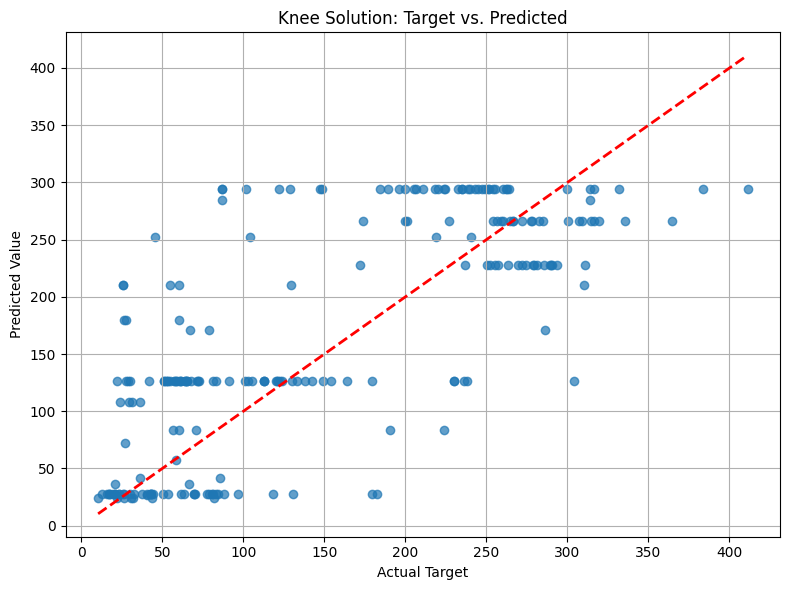

In [ ]:
### knee solution prediction save in excel and plot

def export_predictions_to_excel(individual, filename="train_2obj_knee_predictions.xlsx"):
    y_true = individual.y
    try:
        y_pred = [individual.tree.evaluate(row) for row in individual.X]
    except Exception:
        y_pred = [None] * len(individual.y)

    df = pd.DataFrame({
        "Actual": y_true,
        "Predicted": y_pred
    })

    df.to_excel(filename, index=False, float_format="%.10f")
    print(f"Predictions exported to: {filename}")

export_predictions_to_excel(knee, "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_2obj_knee_predictions.xlsx")

import matplotlib.pyplot as plt
import numpy as np

def plot_knee_predictions(knee_individual):
    y_true = knee_individual.y
    y_pred = [knee_individual.tree.evaluate(row) for row in knee_individual.X]

    # Convert to numpy arrays for plotting
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true, y_pred, alpha=0.7)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Target")
    plt.ylabel("Predicted Value")
    plt.title("Knee Solution: Target vs. Predicted")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_knee_predictions(knee)


In [ ]:
for ind in sorted(pareto_front, key=lambda x: -x.r2):
    if ind.r2 > 0:
        print(f"R²: {ind.r2:.4f}, Complexity: {ind.complexity:.4f}, Expr: {ind.readable}")


R²: 0.6190, Complexity: 3.7500, Expr: +(+(*(lithology, 6.89), geomorphology), geomorphology)
R²: 0.6190, Complexity: 3.7500, Expr: +(+(geomorphology, geomorphology), *(lithology, 6.89))
R²: 0.6190, Complexity: 3.7500, Expr: +(*(lithology, 6.89), +(geomorphology, geomorphology))
R²: 0.6190, Complexity: 3.7500, Expr: +(geomorphology, +(*(lithology, 6.89), geomorphology))
R²: 0.6190, Complexity: 3.7500, Expr: +(+(geomorphology, *(lithology, 6.89)), geomorphology)
R²: 0.6190, Complexity: 3.7500, Expr: +(geomorphology, +(geomorphology, *(lithology, 6.89)))
R²: 0.6107, Complexity: 2.7500, Expr: +(*(lithology, 9.05), geomorphology)
R²: 0.6107, Complexity: 2.7500, Expr: +(geomorphology, *(lithology, 9.05))
R²: 0.4906, Complexity: 1.2500, Expr: *(lithology, LULC)


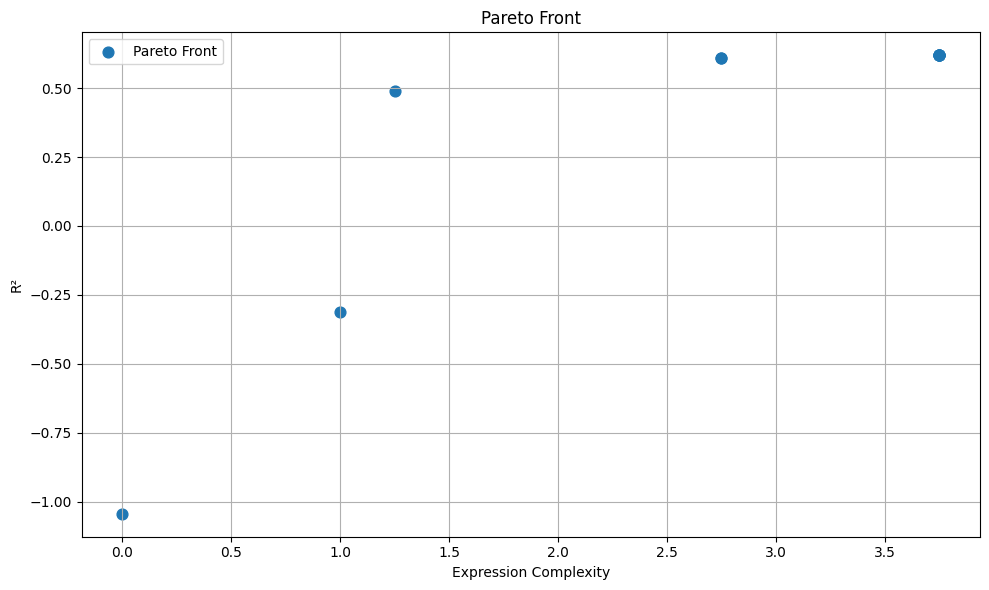

In [ ]:
# plot pareto Front

import matplotlib.pyplot as plt
import numpy as np

def plot_pareto_front(pareto_front, knee_individual=None):
    # Extract complexity (x) and R² (y)
    complexities = [ind.complexity for ind in pareto_front]
    r2_scores = [ind.r2 for ind in pareto_front]

    # Plot Pareto front
    plt.figure(figsize=(10, 6))
    plt.scatter(complexities, r2_scores, label='Pareto Front', s=60)
    #plt.scatter(r2_scores, complexities, label='Pareto Front', s=60)

    # Highlight knee if provided
    # if knee:
    #     plt.scatter(knee.complexity, knee.r2, color='red', s=100, label='Knee Point')
    #     plt.annotate('Knee', (knee.complexity, knee.r2),
    #                  textcoords="offset points", xytext=(0,10), ha='center', color='red')

    plt.xlabel("Expression Complexity")
    plt.ylabel("R²")
    plt.title("Pareto Front")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_pareto_front(pareto_front, knee)


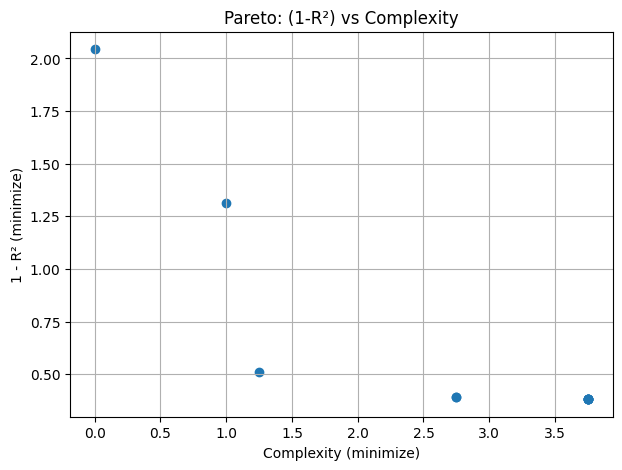

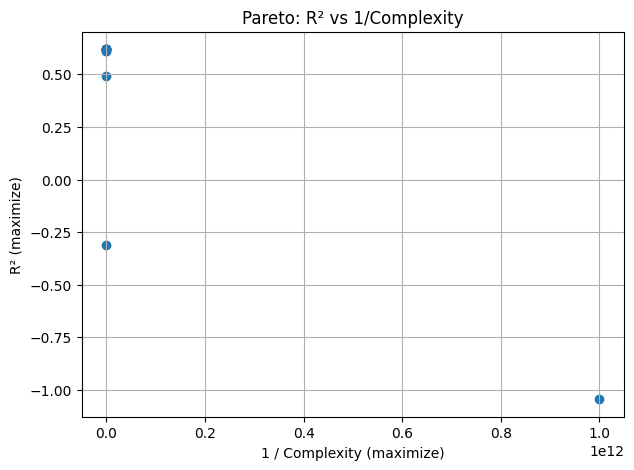

In [ ]:
#### Plot (1 − R²) vs Complexity

import matplotlib.pyplot as plt

def plot_pareto_1_minus_r2_vs_complexity(pareto_front, title=None):
    """
    Minimization-style plot:
      x = complexity (minimize)
      y = 1 - R²      (minimize)
    Best region is bottom-left.
    """
    x_complexity = [ind.complexity for ind in pareto_front]
    y_1_minus_r2 = [1.0 - ind.r2 for ind in pareto_front]

    plt.figure(figsize=(7, 5))
    plt.scatter(x_complexity, y_1_minus_r2)

    plt.xlabel("Complexity (minimize)")
    plt.ylabel("1 - R² (minimize)")
    if title:
        plt.title(title)
    plt.grid(True)
    plt.show()


### Plot R² vs 1/Complexity.  ###

def plot_pareto_r2_vs_inv_complexity(pareto_front, title=None, eps=1e-12):
    """
    Maximization-style visualization:
      x = 1 / complexity (maximize; higher = simpler)
      y = R²             (maximize)
    Best region is top-right.
    """
    x_inv_complexity = [1.0 / (ind.complexity + eps) for ind in pareto_front]
    y_r2 = [ind.r2 for ind in pareto_front]

    plt.figure(figsize=(7, 5))
    plt.scatter(x_inv_complexity, y_r2)

    plt.xlabel("1 / Complexity (maximize)")
    plt.ylabel("R² (maximize)")
    if title:
        plt.title(title)
    plt.grid(True)
    plt.show()

plot_pareto_1_minus_r2_vs_complexity(pareto_front, title="Pareto: (1-R²) vs Complexity")

plot_pareto_r2_vs_inv_complexity(pareto_front, title="Pareto: R² vs 1/Complexity")

In [ ]:
def find_weighted_best_solution(pareto_front, alpha=1.0, beta=0.05):
    def score(ind):
        return alpha * ind.r2 - beta * ind.complexity
    return max(pareto_front, key=score)

# Usage:
weighted_best = find_weighted_best_solution(pareto_front, alpha=1.0, beta=0.05)
print(f"\nWeighted Best Solution:\nR²: {weighted_best.r2:.4f}, Size: {weighted_best.complexity}, Expr: {weighted_best.readable}")



Weighted Best Solution:
R²: 0.6107, Size: 2.75, Expr: +(*(lithology, 9.05), geomorphology)


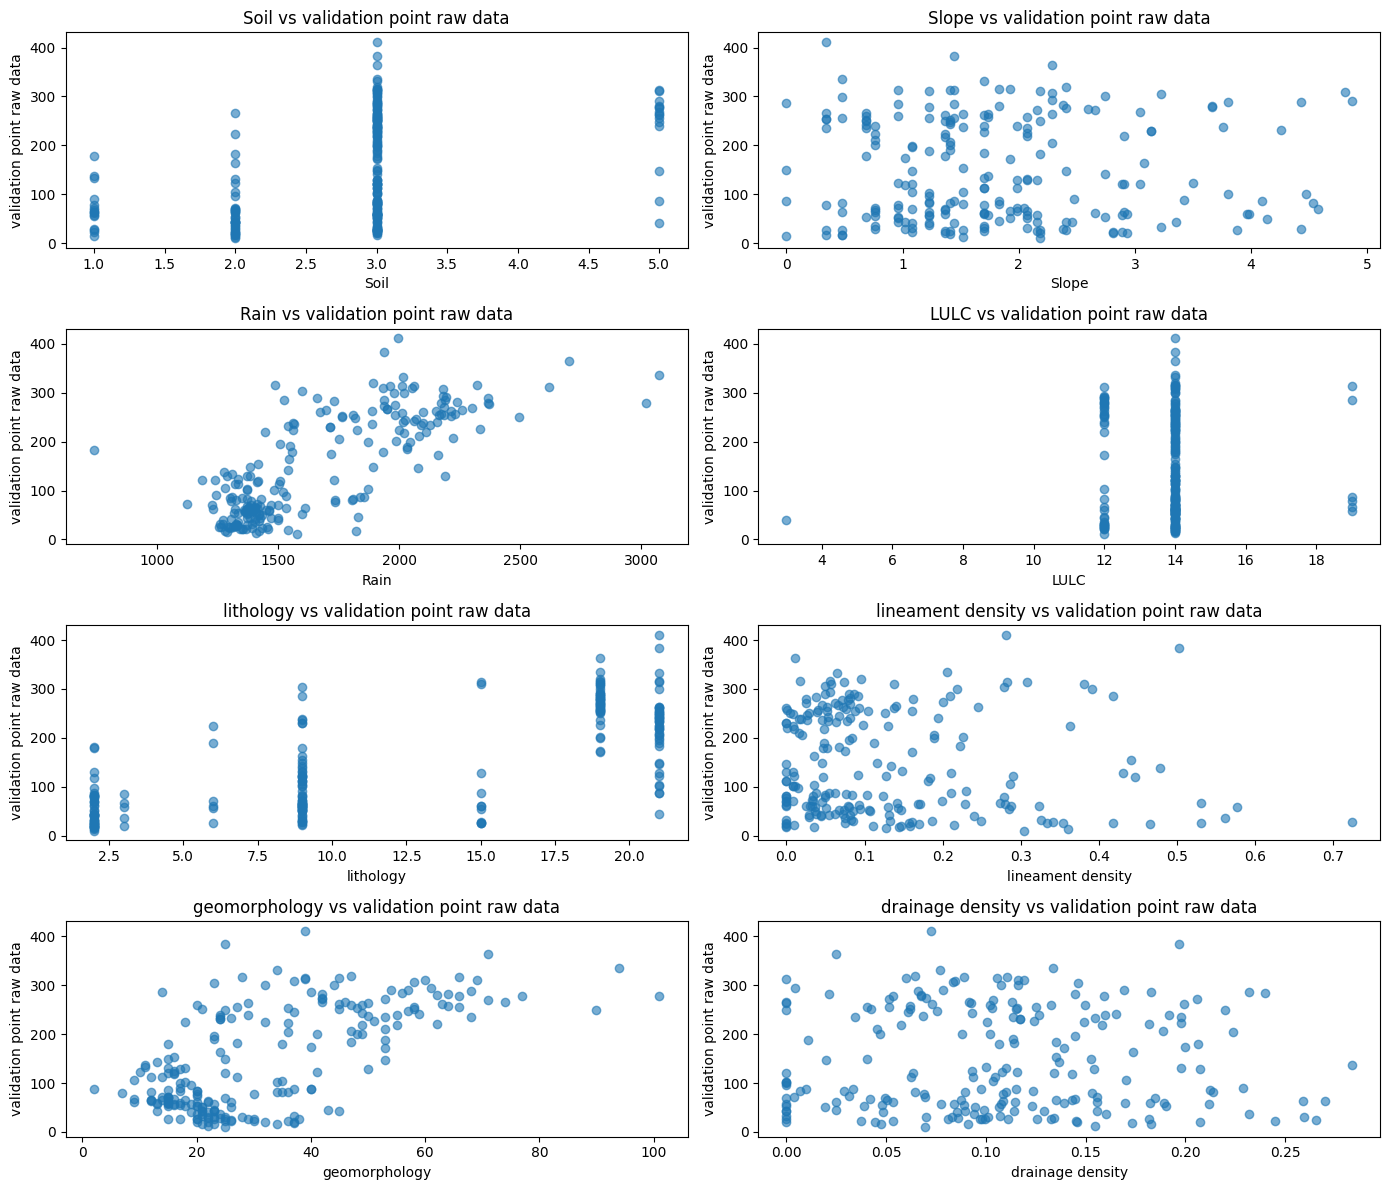

In [ ]:
###Plot feature vs target data --tarin219_dataset.csv

import matplotlib.pyplot as plt


fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
axes = axes.ravel()

for i, feature in enumerate(FEATURE_COLUMNS):
    axes[i].scatter(df[feature], df[TARGET_COLUMN], alpha=0.6)
    axes[i].set_title(f"{feature} vs {TARGET_COLUMN}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(TARGET_COLUMN)

plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['FID', 'Shape', 'WellID', 'type', 'Latitude', 'Longitude', 'NewID', 'Unnamed: 7', 'OldID', 'LULC', 'drainage density', 'geomorphology', 'Soil', 'Slope', 'Rain', 'lithology', 'lineament density', 'validation point categorical data', 'validation point raw data']


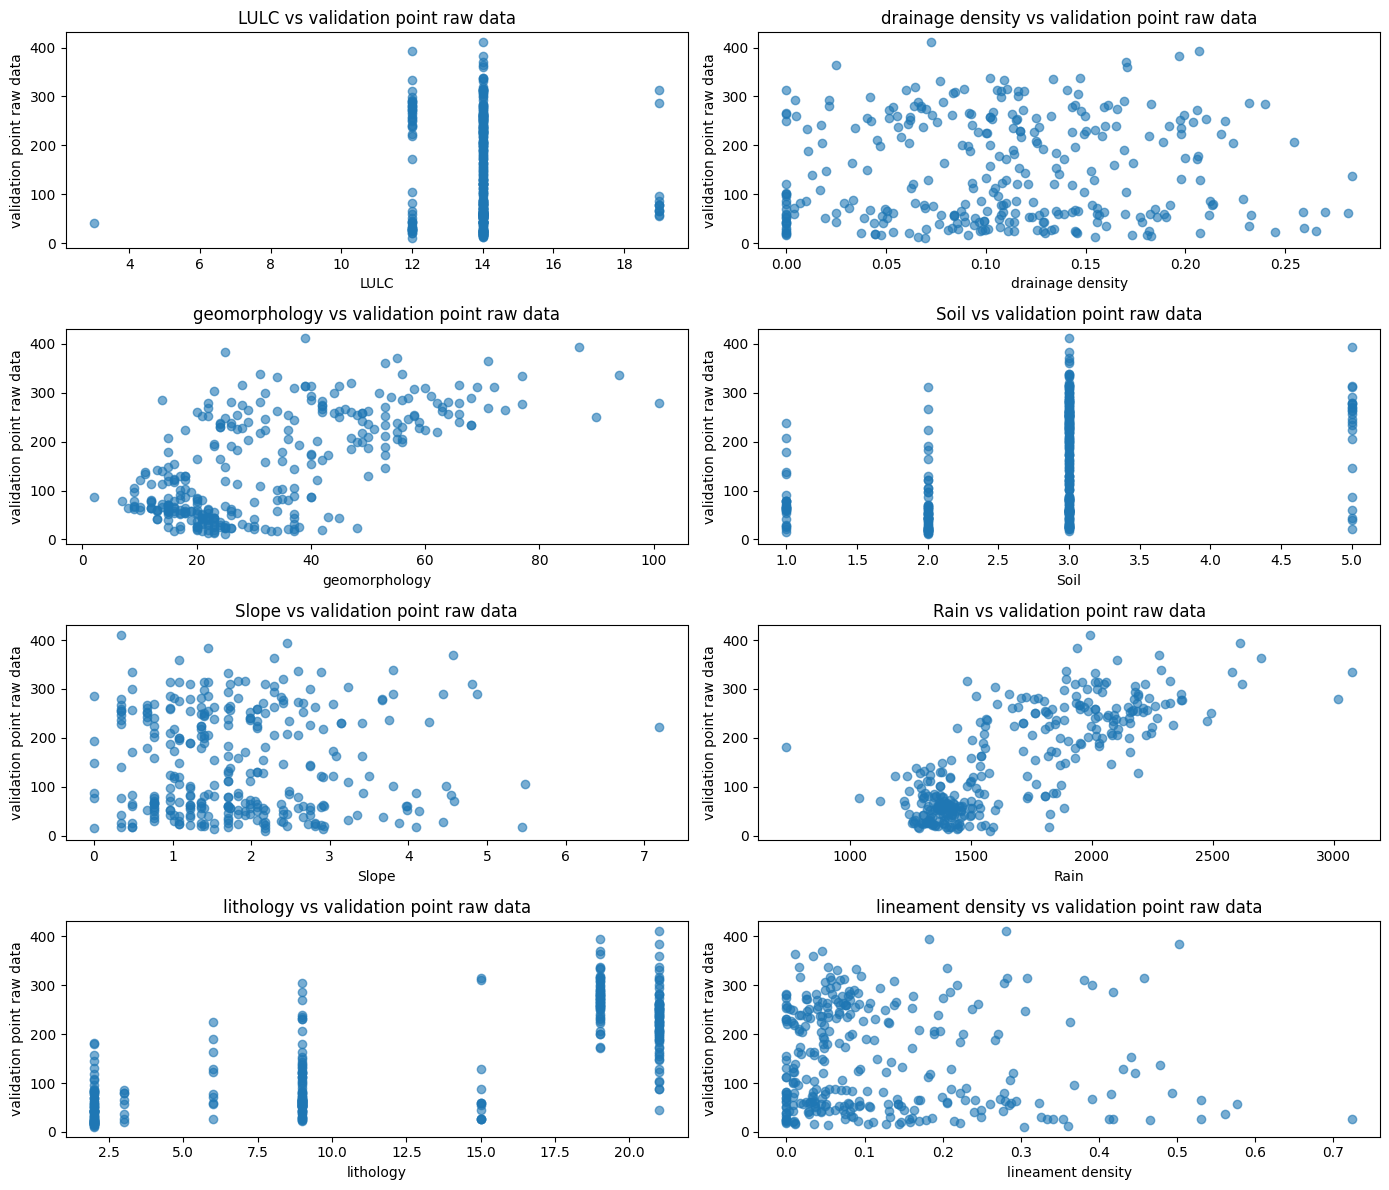

In [ ]:
###Plot feature vs target data GW_potential_8Indicator_318pointsData.xlsx

from google.colab import drive
drive.mount('/content/drive')
file_path = "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/GW_potential_8Indicator_318pointsData.xlsx"
import pandas as pd
df = pd.read_excel(file_path)
df.head()

print(df.columns.tolist())


FEATURE_COLUMNS = ['LULC', 'drainage density', 'geomorphology', 'Soil', 'Slope', 'Rain', 'lithology', 'lineament density']
TARGET_COLUMN = 'validation point raw data'

#Plot feature vs target
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 12))
axes = axes.ravel()

for i, feature in enumerate(FEATURE_COLUMNS[:8]):  # Only plot 8 indicators
    axes[i].scatter(df[feature], df[TARGET_COLUMN], alpha=0.6)
    axes[i].set_title(f"{feature} vs {TARGET_COLUMN}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel(TARGET_COLUMN)

plt.tight_layout()
plt.show()


#df = pd.read_excel("content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/GW_potential_8Indicator_318pointsData.xls")

In [ ]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
## extract validation test99 datasets

#file paths
full_data_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/GW_potential_8Indicator_318pointsData.xlsx'
training_data_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_dataset.csv'

#Load datasets
df_full = pd.read_excel(full_data_path)
df_train = pd.read_csv(training_data_path)

#Choose key columns for comparison
key_columns = ['FID']

#Drop duplicates and perform anti-join
df_full_unique = df_full.drop_duplicates(subset=key_columns)
df_train_unique = df_train.drop_duplicates(subset=key_columns)

df_validation = df_full_unique[~df_full_unique['FID'].isin(df_train_unique['FID'])]



validation_output_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/validation_test99_dataset.csv'
df_validation.to_csv(validation_output_path, index=False)

In [ ]:
import re

pareto_file_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_pareto_front.txt'


parsed_expressions = []

with open(pareto_file_path, 'r') as file:
    for line in file:
        #print("READ LINE:", line.strip())  # See what’s being read
        #match = re.match(r"R²:\s*([-\d.]+),\s*Complexity:\s*(\d+),\s*Expr:\s*(.+)", line.strip())
        match = re.match(r"R²:\s*([-\d.]+),\s*Complexity:\s*([-\d.]+),\s*Expr:\s*(.+)", line.strip())

        if match:
            r2 = float(match.group(1))
            complexity = float(match.group(2))
            expression = match.group(3).strip()
            parsed_expressions.append({
                "r2": r2,
                "complexity": complexity,
                "expression": expression
            })

# Preview parsed expressions
for exp in parsed_expressions:
    print(exp)


{'r2': -1.044, 'complexity': 0.0, 'expression': 'geomorphology'}
{'r2': 0.4906, 'complexity': 1.25, 'expression': '*(lithology, LULC)'}
{'r2': -0.3132, 'complexity': 1.0, 'expression': '+(geomorphology, geomorphology)'}
{'r2': 0.619, 'complexity': 3.75, 'expression': '+(+(*(lithology, 6.89), geomorphology), geomorphology)'}
{'r2': 0.619, 'complexity': 3.75, 'expression': '+(+(geomorphology, geomorphology), *(lithology, 6.89))'}
{'r2': 0.619, 'complexity': 3.75, 'expression': '+(*(lithology, 6.89), +(geomorphology, geomorphology))'}
{'r2': 0.619, 'complexity': 3.75, 'expression': '+(geomorphology, +(*(lithology, 6.89), geomorphology))'}
{'r2': 0.619, 'complexity': 3.75, 'expression': '+(+(geomorphology, *(lithology, 6.89)), geomorphology)'}
{'r2': 0.6107, 'complexity': 2.75, 'expression': '+(*(lithology, 9.05), geomorphology)'}
{'r2': 0.6107, 'complexity': 2.75, 'expression': '+(geomorphology, *(lithology, 9.05))'}
{'r2': 0.619, 'complexity': 3.75, 'expression': '+(geomorphology, +(geom

In [ ]:
##tree root



# Parse prefix expression to Node tree
def parse_prefix(expr_str):
    tokens = expr_str.replace('(', ' ( ').replace(')', ' ) ').replace(',', ' ').split()

    def parse_tokens(tokens):
        if not tokens:
            return None
        token = tokens.pop(0)
        if token in OPERATORS:
            func, arity = OPERATORS[token]
            children = [parse_tokens(tokens) for _ in range(arity)]
            return Node(token, children)
        elif token not in ['(', ')']:
            return Node(token)
        else:
            return parse_tokens(tokens)  # skip parens or commas

    return parse_tokens(tokens)


# Convert expressions to trees
# Parse prefix trees BEFORE writing Excel
for i, exp in enumerate(parsed_expressions):
    exp['tree'] = parse_prefix(exp['expression'])
    print(f"[Expr {i+1}] Tree root: {exp['tree'].name}, Expression: {exp['expression']}")



[Expr 1] Tree root: geomorphology, Expression: geomorphology
[Expr 2] Tree root: *, Expression: *(lithology, LULC)
[Expr 3] Tree root: +, Expression: +(geomorphology, geomorphology)
[Expr 4] Tree root: +, Expression: +(+(*(lithology, 6.89), geomorphology), geomorphology)
[Expr 5] Tree root: +, Expression: +(+(geomorphology, geomorphology), *(lithology, 6.89))
[Expr 6] Tree root: +, Expression: +(*(lithology, 6.89), +(geomorphology, geomorphology))
[Expr 7] Tree root: +, Expression: +(geomorphology, +(*(lithology, 6.89), geomorphology))
[Expr 8] Tree root: +, Expression: +(+(geomorphology, *(lithology, 6.89)), geomorphology)
[Expr 9] Tree root: +, Expression: +(*(lithology, 9.05), geomorphology)
[Expr 10] Tree root: +, Expression: +(geomorphology, *(lithology, 9.05))
[Expr 11] Tree root: +, Expression: +(geomorphology, +(geomorphology, *(lithology, 6.89)))


In [ ]:
#pareto_validation_results for each pareto font saved in excel file

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

validation_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/validation_test99_dataset.csv'
output_excel_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_pareto_validation_results.xlsx'


FEATURE_COLUMNS = ['Soil', 'Slope', 'Rain', 'LULC', 'lithology', 'lineament density', 'geomorphology', 'drainage density']
TARGET_COLUMN = 'Net Groundwater Recharge'

# Map feature names to indices
feature_map = {name: idx for idx, name in enumerate(FEATURE_COLUMNS)}

# Load validation data
df_val = pd.read_csv(validation_path)
X_val = df_val[FEATURE_COLUMNS].values
y_val = df_val[TARGET_COLUMN].values

r2_comparison_data = []  # To store (index, train_r2, val_r2, complexity)


with pd.ExcelWriter(output_excel_path, engine='openpyxl') as writer:
    for i, exp in enumerate(parsed_expressions):
        preds = []
        print(f"\n[Expr {i+1}] {exp['expression']}")

        # Custom feature mapping just for Expr 7
        custom_map = feature_map.copy()
        if i == 6:  # Expr 7 is at index 6 (0-based)
            custom_map['lineament'] = custom_map['lineament density']

        for idx, row in enumerate(X_val):
            try:
                pred = exp['tree'].evaluate(row, custom_map)
            except Exception as e:
                if idx == 0:
                    print(f"[Expr {i+1}] Evaluation error on first row: {e}")
                pred = None
            preds.append(pred)

        exp['predictions'] = preds

        # Compute R²
        try:
            r2_val = r2_score(y_val, preds)

        except:
            r2_val = -np.inf

        # Compute MSE, RMSE, MAE to console
        valid_pairs = [(y, p) for y, p in zip(y_val, preds) if p is not None and not np.isnan(p)]
        if valid_pairs:
            y_clean, preds_clean = zip(*valid_pairs)
            mse_val = mean_squared_error(y_clean, preds_clean)
            rmse_val = np.sqrt(mse_val)
            mae_val = mean_absolute_error(y_clean, preds_clean)
        else:
            mse_val = rmse_val = mae_val = np.nan

        #print(f"R2 (validation datasets): {r2_val:.4f} MSE: {mse_val:.4f}, RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}")
        train_r2 = pareto_front[i].r2  # for training R²
        complexity = pareto_front[i].complexity
        print(f"R2 (train): {train_r2:.4f} Complexity: {complexity:.4f} \nR2 (validation): {r2_val:.4f} \nMSE: {mse_val:.4f}, RMSE: {rmse_val:.4f}, MAE: {mae_val:.4f}")
        r2_comparison_data.append((i + 1, train_r2, r2_val, complexity))


        # Combine features, actual, and predicted
        df_result = df_val[FEATURE_COLUMNS].copy()
        df_result['Actual'] = y_val
        df_result['Predicted'] = preds

        # Add header with R² and complexity and expression
        header_df = pd.DataFrame({
            f'R²: {r2_val:.4f}, Complexity: {exp["complexity"]}, Expression: {exp["expression"]}': []
        })

        # Write to sheet
        sheet_name = f'Expr_{i+1}'
        header_df.to_excel(writer, sheet_name=sheet_name, index=False)
        df_result.to_excel(writer, sheet_name=sheet_name, index=False, startrow=2)




[Expr 1] geomorphology
R2 (train): -1.0440 Complexity: 0.0000 
R2 (validation): -1.0687 
MSE: 22730.1186, RMSE: 150.7651, MAE: 119.0749

[Expr 2] *(lithology, LULC)
R2 (train): 0.4906 Complexity: 1.2500 
R2 (validation): 0.5186 
MSE: 5288.8127, RMSE: 72.7242, MAE: 59.6051

[Expr 3] +(geomorphology, geomorphology)
R2 (train): -0.3132 Complexity: 1.0000 
R2 (validation): -0.3445 
MSE: 14772.5569, RMSE: 121.5424, MAE: 94.6545

[Expr 4] +(+(*(lithology, 6.89), geomorphology), geomorphology)
R2 (train): 0.6190 Complexity: 3.7500 
R2 (validation): 0.7090 
MSE: 3196.9684, RMSE: 56.5417, MAE: 46.9848

[Expr 5] +(+(geomorphology, geomorphology), *(lithology, 6.89))
R2 (train): 0.6190 Complexity: 3.7500 
R2 (validation): 0.7090 
MSE: 3196.9684, RMSE: 56.5417, MAE: 46.9848

[Expr 6] +(*(lithology, 6.89), +(geomorphology, geomorphology))
R2 (train): 0.6190 Complexity: 3.7500 
R2 (validation): 0.7090 
MSE: 3196.9684, RMSE: 56.5417, MAE: 46.9848

[Expr 7] +(geomorphology, +(*(lithology, 6.89), geom

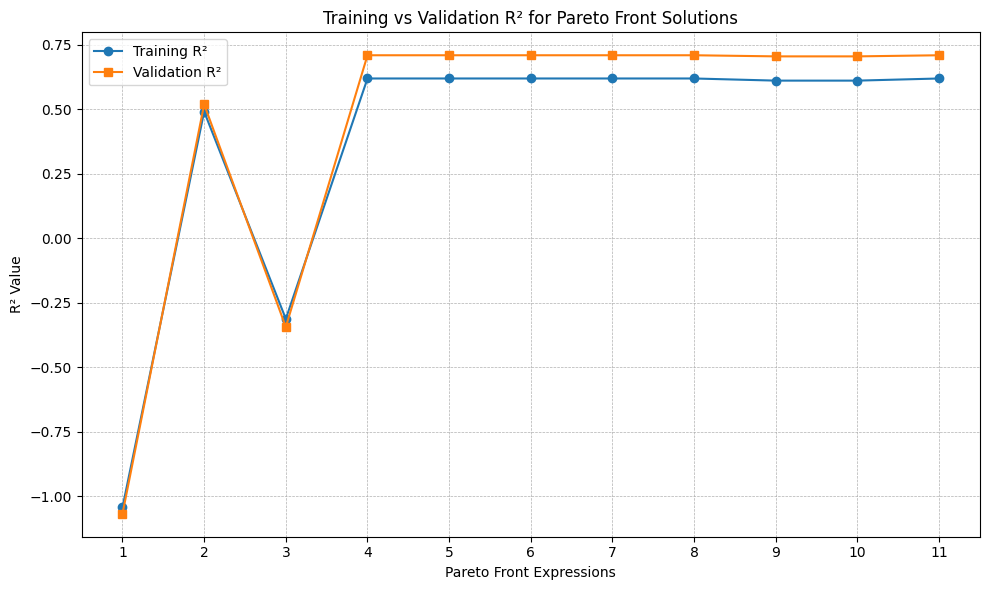

In [ ]:
import matplotlib.pyplot as plt

# Unpack tracked data
expr_ids, train_r2s, val_r2s, complexities = zip(*r2_comparison_data)

plt.figure(figsize=(10, 6))
plt.plot(expr_ids, train_r2s, marker='o', label='Training R²')
plt.plot(expr_ids, val_r2s, marker='s', label='Validation R²')
plt.xlabel("Pareto Front Expressions")
plt.ylabel("R² Value")
plt.title("Training vs Validation R² for Pareto Front Solutions")
plt.grid(True, linestyle='--', linewidth=0.5)
plt.xticks(expr_ids)
plt.legend()
plt.tight_layout()
plt.show()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


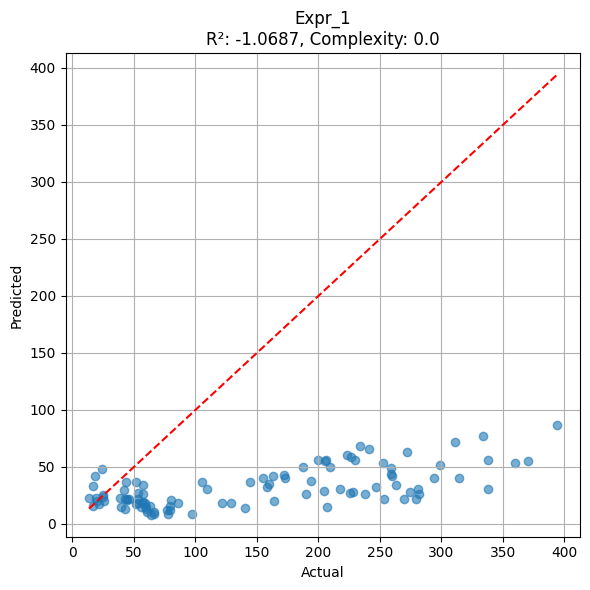

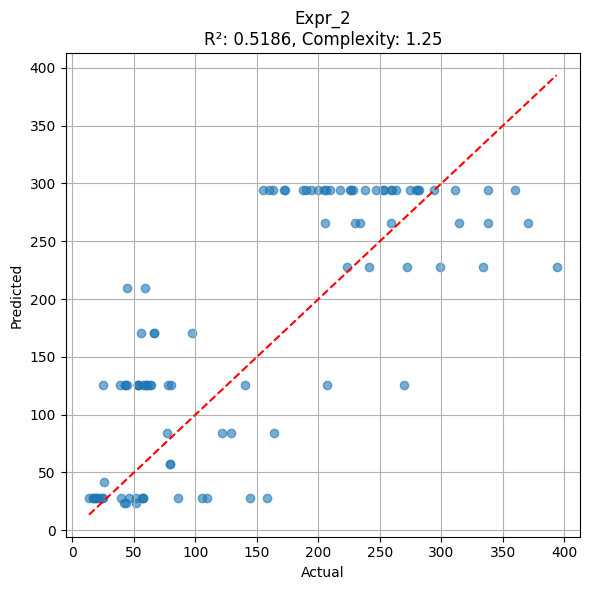

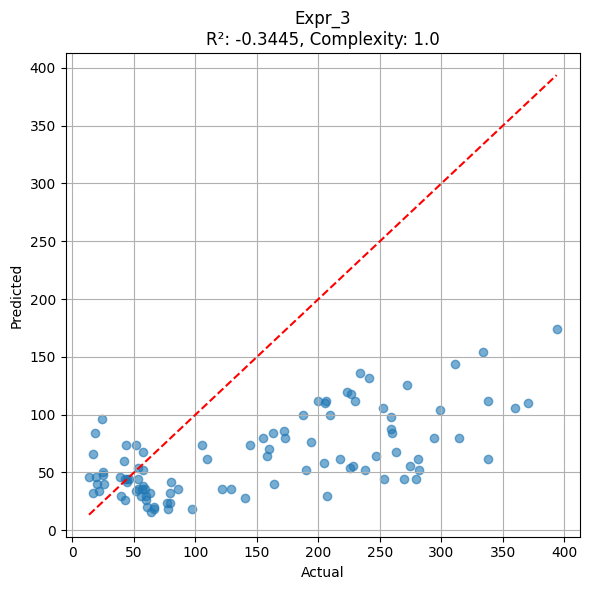

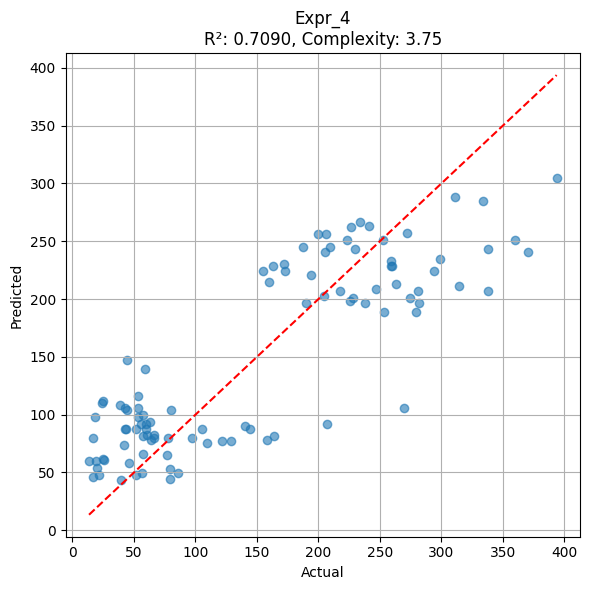

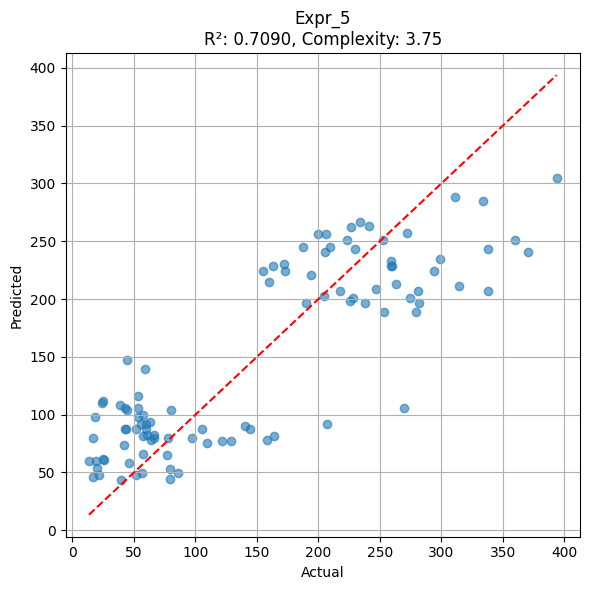

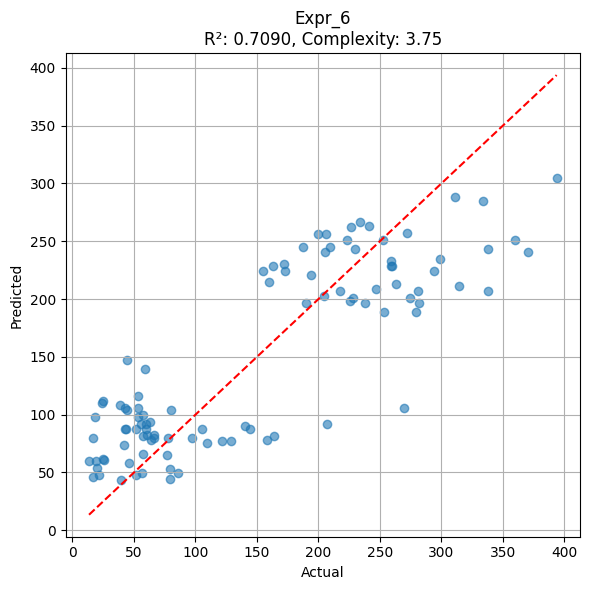

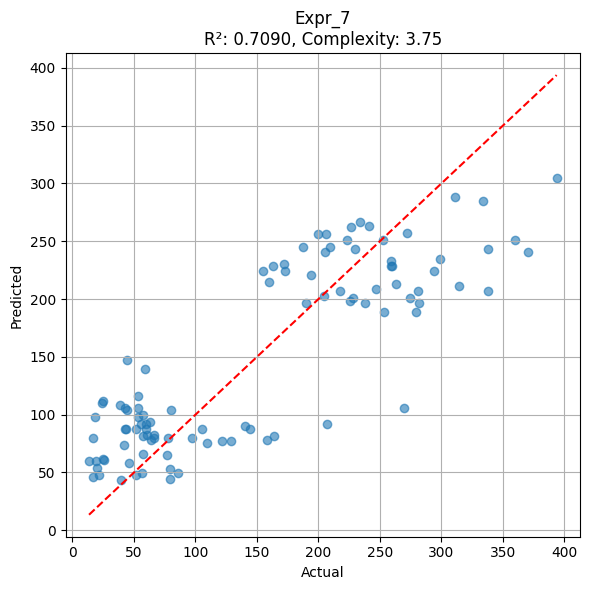

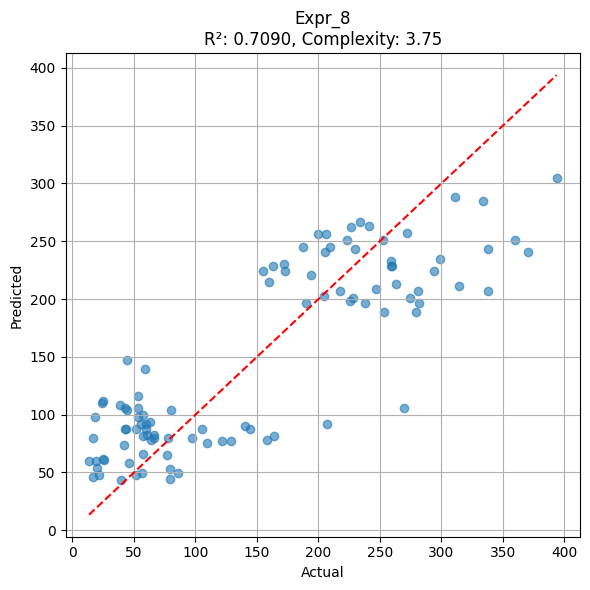

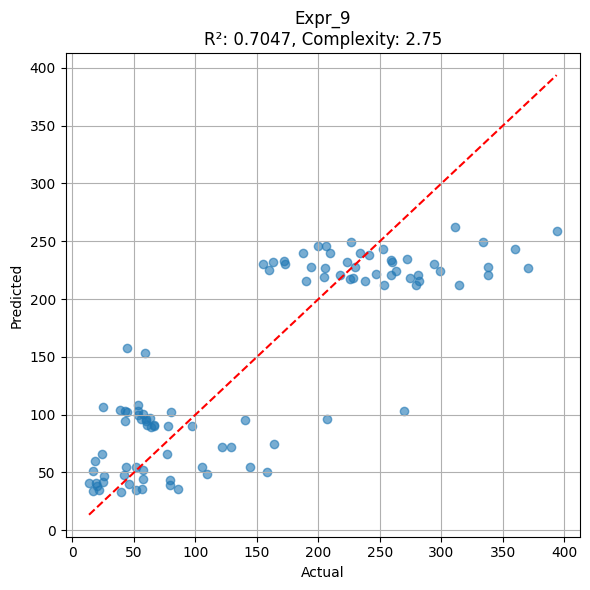

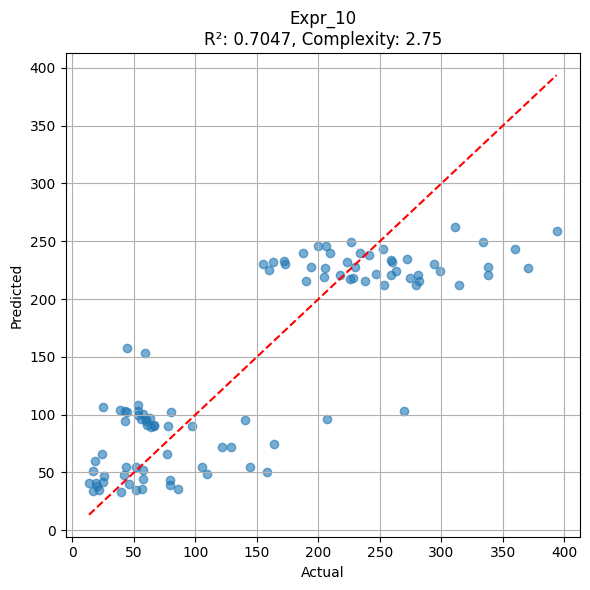

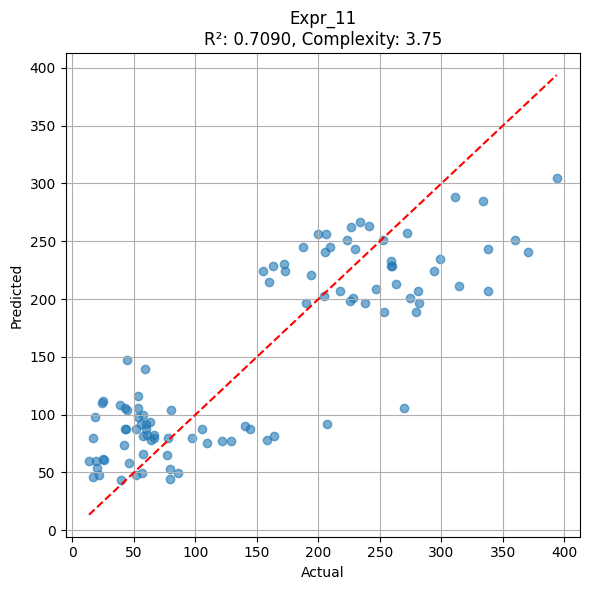

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import re

from google.colab import drive
drive.mount('/content/drive')

excel_path = '/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/train219_pareto_validation_results.xlsx'

# Load the Excel file
xlsx = pd.ExcelFile(excel_path)

# Filter sheets that start with "Expr_"
expr_sheets = [name for name in xlsx.sheet_names if name.startswith("Expr_")]

# Plot actual vs predicted for each sheet individually
for sheet in expr_sheets:
    # Read header (row 0) for meta info
    header_df = pd.read_excel(excel_path, sheet_name=sheet, nrows=1, header=None)
    header_text = str(header_df.iloc[0, 0])

    # Extract R² and complexity using regex
    r2_match = re.search(r'R²:\s*(-?\d+\.\d+)', header_text)
    comp_match = re.search(r'Complexity:\s*(-?\d+\.\d+)', header_text)

    r2_val = r2_match.group(1) if r2_match else "N/A"
    complexity = comp_match.group(1) if comp_match else "N/A"

    # Load data
    df = pd.read_excel(excel_path, sheet_name=sheet, skiprows=2)

    if 'Actual' in df.columns and 'Predicted' in df.columns:
        plt.figure(figsize=(6, 6))
        plt.scatter(df['Actual'], df['Predicted'], alpha=0.6)
        plt.plot([df['Actual'].min(), df['Actual'].max()],
                 [df['Actual'].min(), df['Actual'].max()],
                 'r--', label='Ideal')
        plt.xlabel("Actual")
        plt.ylabel("Predicted")
        plt.title(f"{sheet}\nR²: {r2_val}, Complexity: {complexity}")
        #plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()



In [ ]:
# =========================
# MULTI-RUN WITH CLEAN PRINTING
# =========================

NUM_RUNS = 20  #30
BASE_SEED = 42
SEEDS = [BASE_SEED + i for i in range(NUM_RUNS)]

ALL_PARETO_TXT = "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/MultiObj_all_runs_pareto_fronts.txt"

# Clear file before starting
open(ALL_PARETO_TXT, "w").close()

all_run_pareto_fronts = []

for run_idx, seed in enumerate(SEEDS, start=1):


    print(f"\n RUN {run_idx}\n")


    random.seed(seed)
    np.random.seed(seed)

    # reset logs if you use them
    all_logs = []

    # ---- Evolution ----
    final_pop = run_gp_evolution(
        X=X,
        y=y,
        feature_names=symbolic_variable_map,
        population_size=100,   #150 #120 #100
        generations=100,     #100
        max_depth=6,
        mutation_rate=0.3
    )

    # ---- Pareto ----
    pareto_front = get_pareto_front(final_pop)
    if len(pareto_front) == 0:
        print(f"WARNING: Empty Pareto front for run {run_idx}")
    print(f"\n[SUMMARY] Run {run_idx}: pareto_size={len(pareto_front)} | best_R2={max(ind.r2 for ind in pareto_front):.4f}")
    all_run_pareto_fronts.append(pareto_front)


    print(f"\n FINAL PARETO FRONT — RUN {run_idx} (size={len(pareto_front)})")

    # Print to console
    for ind in pareto_front:
        print(f"R2: {ind.r2:.6f} | Complexity: {ind.complexity:.6f} | Expr: {ind.readable}")

    # Print in single TXT file
    with open(ALL_PARETO_TXT, "a") as f:
        f.write(f"\nPARETO FRONT FOR RUN {run_idx} (size={len(pareto_front)})\n")
        # Write summary line once
        best_r2 = max(ind.r2 for ind in pareto_front)
        f.write(f"Best R2: {best_r2:.4f}\n")
        # Then write each individual
        for ind in pareto_front:
            f.write(f"R2: {ind.r2:.6f} | Complexity: {ind.complexity:.6f} | Expr: {ind.readable}\n")

print("\nAll runs completed.")
print(f"All Pareto fronts saved in: {ALL_PARETO_TXT}")

Streaming output truncated to the last 5000 lines.
[MUTATION] Before mutation (Child2): square(x6)
[MUTATION] After mutation  (Child2): square(x6)
[CROSSOVER] Parent1: *(x6, 3.24)
[CROSSOVER] Parent2: *(x6, 3.24)
[CROSSOVER] Child1 : *(x6, 3.24)
[CROSSOVER] Child2 : *(x6, 3.24)
[MUTATION] Before mutation (Child2): *(x6, 3.24)
[MUTATION] After mutation  (Child2): /(+(exp(x7), x1), *(x2, x1))
[CROSSOVER] Parent1: square(x3)
[CROSSOVER] Parent2: x6
[CROSSOVER] Child1 : square(x6)
[CROSSOVER] Child2 : x3
[CROSSOVER] Parent1: *(+(+(x4, x6), x6), 1.99)
[CROSSOVER] Parent2: +(x6, x6)
[CROSSOVER] Child1 : *(+(+(x6, x6), x6), 1.99)
[CROSSOVER] Child2 : +(x4, x6)
[MUTATION] Before mutation (Child2): +(x4, x6)
[MUTATION] After mutation  (Child2): +(*(/(-(x5, x2), /(x6, x2)), -4.52), x6)
[CROSSOVER] Parent1: x6
[CROSSOVER] Parent2: *(x6, 3.24)
[CROSSOVER] Child1 : *(x6, 3.24)
[CROSSOVER] Child2 : x6
[CROSSOVER] Parent1: *(x6, 3.24)
[CROSSOVER] Parent2: +(*(x6, 3.24), x6)
[CROSSOVER] Child1 : +(*(x

In [ ]:
# =========================
# GLOBAL PARETO FRONT (Front 0 of all runs)---- non-dominated sorting again
# =========================

# Pool all solutions
pooled = []
for pf in all_run_pareto_fronts:
    pooled.extend(pf)

print("Total pooled before duplicate removal:", len(pooled))

# Remove duplicates based on (R2, Complexity)
unique_dict = {}
for ind in pooled:
    key = (round(ind.r2, 10), round(ind.complexity, 10))
    if key not in unique_dict:
        unique_dict[key] = ind

unique_solutions = list(unique_dict.values())

print("After duplicate removal:", len(unique_solutions))

# Compute global Pareto
global_pareto_front = get_pareto_front(unique_solutions) ## non-dominated sorting again

print("Global Pareto size:", len(global_pareto_front))

# save global pareto to txt
GLOBAL_TXT = "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/MultiObj_global_pareto_front.txt"

# Sort by R2 descending
global_pareto_front.sort(key=lambda ind: ind.r2, reverse=True)


print(f"\nGLOBAL PARETO FRONT (Front 0 of all runs - remove duplicates) | size: {len(global_pareto_front)}")
print("="*70)

for ind in global_pareto_front:
    print(f"R2: {ind.r2:.6f} | Complexity: {ind.complexity:.6f} | Expr: {ind.readable}")

with open(GLOBAL_TXT, "w") as f:
    f.write(f"GLOBAL PARETO FRONT (Front 0 of all runs-remove duplicates) | size: {len(global_pareto_front)} \n\n")

    for ind in global_pareto_front:
        f.write(f"R2: {ind.r2:.6f} | Complexity: {ind.complexity:.6f} | Expr: {ind.readable}\n")

print("\nSaved global pareto to:", GLOBAL_TXT)

print(f"\nR2 range: [{min(ind.r2 for ind in global_pareto_front):.4f}, {max(ind.r2 for ind in global_pareto_front):.4f}]")
print(f"Complexity range: [{min(ind.complexity for ind in global_pareto_front)}, {max(ind.complexity for ind in global_pareto_front)}]")

Total pooled before duplicate removal: 2000
After duplicate removal: 89
Global Pareto size: 8

GLOBAL PARETO FRONT (Front 0 of all runs - remove duplicates) | size: 8
R2: 0.612968 | Complexity: 8.000000 | Expr: +(+(*(+(Lithology, Drainage density), +(log(+(Geomorphology, Geomorphology)), 3.0)), Geomorphology), Geomorphology)
R2: 0.611142 | Complexity: 7.000000 | Expr: +(+(*(+(Lithology, Drainage density), +(log(Geomorphology), 3.0)), Geomorphology), Geomorphology)
R2: 0.610945 | Complexity: 3.750000 | Expr: +(*(Lithology, +(-4.67, LULC)), Geomorphology)
R2: 0.558605 | Complexity: 3.500000 | Expr: *(6.31, *(Lithology, 1.85))
R2: 0.549429 | Complexity: 2.000000 | Expr: /(Lithology, 0.09)
R2: 0.490599 | Complexity: 1.250000 | Expr: *(Lithology, LULC)
R2: -0.313185 | Complexity: 1.000000 | Expr: +(Geomorphology, Geomorphology)
R2: -1.043963 | Complexity: 0.000000 | Expr: Geomorphology

Saved global pareto to: /content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/MultiObj_glob

In [ ]:
## Prefix to Infix
## Infix write in Latex (tex)

import re
import os

def prefix_to_infix(expr):
    """Convert prefix expression to infix notation"""
    expr = expr.strip()

    if ',' not in expr and '(' not in expr and ')' not in expr:
        return expr

    match = re.match(r'^([a-zA-Z+\-*/]+)\(', expr)
    if not match:
        return expr

    op = match.group(1)

    depth = 0
    content_start = len(op) + 1
    content_end = -1

    for i in range(content_start, len(expr)):
        if expr[i] == '(':
            depth += 1
        elif expr[i] == ')':
            if depth == 0:
                content_end = i
                break
            else:
                depth -= 1

    if content_end == -1:
        return expr

    content = expr[content_start:content_end]

    args = []
    current_arg = []
    depth = 0

    for char in content:
        if char == '(':
            depth += 1
            current_arg.append(char)
        elif char == ')':
            depth -= 1
            current_arg.append(char)
        elif char == ',' and depth == 0:
            args.append(''.join(current_arg).strip())
            current_arg = []
        else:
            current_arg.append(char)

    if current_arg:
        args.append(''.join(current_arg).strip())

    converted_args = [prefix_to_infix(arg) for arg in args]

    if op in ['+', '-', '*', '/']:
        if len(args) == 2:
            return f"({converted_args[0]} {op} {converted_args[1]})"
    elif op == 'log':
        return f"log({converted_args[0]})"
    elif op == 'sin':
        return f"sin({converted_args[0]})"
    elif op == 'square':
        return f"({converted_args[0]})^2"
    elif op == 'cube':
        return f"({converted_args[0]})^3"
    elif op == 'pow':
        return f"({converted_args[0]})^({converted_args[1]})"
    else:
        return f"{op}({', '.join(converted_args)})"

    return expr

def infix_to_latex(expr):
    """Convert infix expression to LaTeX format (paper safe)."""

    # Escape LaTeX special characters (feature names often have _)
    expr = expr.replace('&', r'\&')
    expr = expr.replace('%', r'\%')
    expr = expr.replace('_', r'\_')

    # Functions
    expr = expr.replace('sin(', r'\sin(')
    expr = expr.replace('cos(', r'\cos(')
    expr = expr.replace('log(', r'\log(')
    expr = expr.replace('exp(', r'\exp(')

    # Multiplication
    expr = expr.replace('*', r' \cdot ')

    return expr

# File paths
file_path = r"/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/MultiObj_global_pareto_front.txt"
infix_output_path = r"/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/MultiObj_global_pareto_INFIX_format.txt"
latex_output_path = r"/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/MultiObj_global_pareto_latex.tex"

print("="*80)
print("CONVERTING ALL EXPRESSIONS TO INFIX")
print("="*80)

try:
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # Store all expressions
    expressions = []

    print("\nPROCESSING EXPRESSIONS:")
    print("-"*60)

    for i, line in enumerate(lines, 1):
        line = line.strip()
        if line.startswith("R2:"):
            parts = line.split("|")
            r2 = parts[0].replace("R2:", "").strip()
            complexity = parts[1].replace("Complexity:", "").strip()
            expr = parts[2].replace("Expr:", "").strip()

            # Convert to infix
            infix = prefix_to_infix(expr)

            expressions.append({
                'r2': r2,
                'complexity': complexity,
                'prefix': expr,
                'infix': infix
            })

    # Print ALL expressions to console (PREFIX + INFIX)
    print(f"\n{'='*80}")
    print(f"ALL {len(expressions)} EXPRESSIONS - PREFIX vs INFIX")
    print(f"{'='*80}")

    for i, exp in enumerate(expressions, 1):
        print(f"\n{i:2d}. R²: {exp['r2']} | Complexity: {exp['complexity']}")
        print(f"   PREFIX: {exp['prefix']}")
        print(f"   INFIX : {exp['infix']}")
        print(f"   {'-'*50}")

    # Save ONLY INFIX to text file
    with open(infix_output_path, 'w') as f:
        f.write("="*80 + "\n")
        f.write(f"INFIX EXPRESSIONS FROM GLOBAL PARETO FRONT ({len(expressions)} equations)\n")
        f.write("="*80 + "\n\n")

        for i, exp in enumerate(expressions, 1):
            f.write(f"{i:2d}. R²: {exp['r2']} | Complexity: {exp['complexity']}\n")
            f.write(f"   INFIX EXPRESSION: {exp['infix']}\n\n")

    print(f"\n{'='*80}")
    print(f"✅ Saved INFIX ONLY to: {infix_output_path}")

    # Also generate LaTeX
    with open(latex_output_path, 'w') as f:
        f.write(r"\begin{table}[h]" + "\n")
        f.write(r"\centering" + "\n")
        ##f.write(r"\small" + "\n")
        f.write(r"\caption{Pareto-optimal expressions from symbolic regression}" + "\n")
        f.write(r"\label{tab:pareto_front}" + "\n")

        f.write(r"\setlength{\tabcolsep}{4pt}" + "\n")
        f.write(r"\renewcommand{\arraystretch}{1.1}" + "\n")
        f.write(r"\begin{tabularx}{\textwidth}{|c|c|>{\raggedright\arraybackslash}X|}" + "\n")
        f.write(r"\hline" + "\n")

        f.write(r"R\textsuperscript{2} & Complexity & Expression \\" + "\n")
        f.write(r"\hline" + "\n")

        for exp in expressions:
            latex_expr = infix_to_latex(exp['infix'])
            r2_formatted = f"{float(exp['r2']):.6f}"
            complexity_formatted = f"{float(exp['complexity']):.2f}"
            f.write(f"{r2_formatted} & {complexity_formatted} & \\raggedright ${latex_expr}$ \\\\" + "\n")
            f.write(r"\hline" + "\n")

        f.write(r"\end{tabularx}" + "\n")
        f.write(r"\end{table}" + "\n")

    print(f"✅ Also saved LaTeX table to: {latex_output_path}")
    print("="*80)

except FileNotFoundError:
    print(f"❌ File not found: {file_path}")
except Exception as e:
    print(f"❌ Error: {e}")

CONVERTING ALL EXPRESSIONS TO INFIX

PROCESSING EXPRESSIONS:
------------------------------------------------------------

ALL 8 EXPRESSIONS - PREFIX vs INFIX

 1. R²: 0.612968 | Complexity: 8.000000
   PREFIX: +(+(*(+(Lithology, Drainage density), +(log(+(Geomorphology, Geomorphology)), 3.0)), Geomorphology), Geomorphology)
   INFIX : ((((Lithology + Drainage density) * (log((Geomorphology + Geomorphology)) + 3.0)) + Geomorphology) + Geomorphology)
   --------------------------------------------------

 2. R²: 0.611142 | Complexity: 7.000000
   PREFIX: +(+(*(+(Lithology, Drainage density), +(log(Geomorphology), 3.0)), Geomorphology), Geomorphology)
   INFIX : ((((Lithology + Drainage density) * (log(Geomorphology) + 3.0)) + Geomorphology) + Geomorphology)
   --------------------------------------------------

 3. R²: 0.610945 | Complexity: 3.750000
   PREFIX: +(*(Lithology, +(-4.67, LULC)), Geomorphology)
   INFIX : ((Lithology * (-4.67 + LULC)) + Geomorphology)
   -------------------

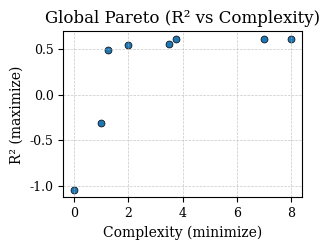

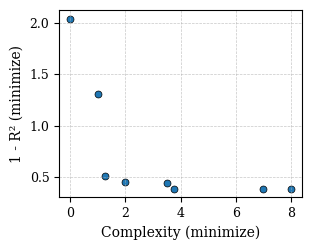

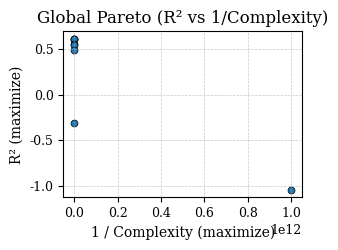

In [ ]:
## PLOT GLOBAL PARETO

import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,

    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8
})

#Plot 1: Complexity vs R²
def plot_global_pareto_r2_vs_complexity(global_pareto_front, title="Global Pareto (R² vs Complexity)"):
    x = [ind.complexity for ind in global_pareto_front]
    y = [ind.r2 for ind in global_pareto_front]

    #plt.figure(figsize=(7, 5))
    plt.figure(figsize=(3.3, 2.6))
    plt.scatter(x, y, s=25, edgecolors='black', linewidths=0.5)

    # Sort points for line
    # points = sorted(zip(x, y))
    # x_sorted, y_sorted = zip(*points)
    # plt.plot(x_sorted, y_sorted, linewidth=1.2)

    plt.xlabel("Complexity (minimize)")
    plt.ylabel("R² (maximize)")
    plt.title(title)
    #plt.grid(True)
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    #plt.savefig("/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/Figure_pdf/plot_r2_vs_complexity.pdf", bbox_inches='tight')
    plt.show()

plot_global_pareto_r2_vs_complexity(global_pareto_front)


#Plot 2: Complexity vs (1 − R²) (both minimize, bottom-left is best)
#def plot_global_pareto_1mr2_vs_complexity(global_pareto_front, title="Global Pareto ((1-R²) vs Complexity)"):
def plot_global_pareto_1mr2_vs_complexity(global_pareto_front):
    x = [ind.complexity for ind in global_pareto_front]
    y = [1.0 - ind.r2 for ind in global_pareto_front]

    #plt.figure(figsize=(7, 5))
    plt.figure(figsize=(3.3, 2.6))
    plt.scatter(x, y, s=25, edgecolors='black', linewidths=0.5)

    # Sort points for line
    # points = sorted(zip(x, y))
    # x_sorted, y_sorted = zip(*points)
    # plt.plot(x_sorted, y_sorted, linewidth=1.2)

    plt.xlabel("Complexity (minimize)")
    plt.ylabel("1 - R² (minimize)")
    #plt.title(title)
    #plt.grid(True)
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.savefig("/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/Figure_pdf/plot_pareto_front.pdf", bbox_inches='tight')
    plt.show()

plot_global_pareto_1mr2_vs_complexity(global_pareto_front)



#Plot 3: R² vs 1/Complexity (both maximize top-right is best)
def plot_global_pareto_r2_vs_inv_complexity(global_pareto_front, title="Global Pareto (R² vs 1/Complexity)", eps=1e-12):
    x = [1.0 / (ind.complexity + eps) for ind in global_pareto_front]
    y = [ind.r2 for ind in global_pareto_front]

    #plt.figure(figsize=(7, 5))
    plt.figure(figsize=(3.3, 2.6))
    plt.scatter(x, y, s=25, edgecolors='black', linewidths=0.5)

    # Sort points for line
    # points = sorted(zip(x, y))
    # x_sorted, y_sorted = zip(*points)
    # plt.plot(x_sorted, y_sorted, linewidth=1.2)


    plt.xlabel("1 / Complexity (maximize)")
    plt.ylabel("R² (maximize)")
    plt.title(title)
    #plt.grid(True)
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    #plt.savefig("/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/Figure_pdf/plot_r2_vs_1_by_complexity.pdf", bbox_inches='tight')
    plt.show()

plot_global_pareto_r2_vs_inv_complexity(global_pareto_front)

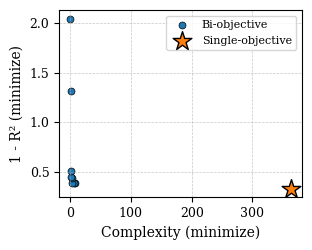

In [ ]:
## Plot both bi-objective apareto front and single objective best expression

import matplotlib.pyplot as plt

def plot_global_pareto_1mr2_vs_complexity(
    global_pareto_front,
    best_complexity=None,
    best_r2=None,
    title="Global Pareto ((1-R²) vs Complexity)"
):
    x = [ind.complexity for ind in global_pareto_front]
    y = [1.0 - ind.r2 for ind in global_pareto_front]

    #plt.figure(figsize=(7, 5))
    plt.figure(figsize=(3.3, 2.6))

    # Pareto solutions (only scatter)
    plt.scatter(x, y, s=25, edgecolors='black', linewidths=0.5,
                label="Bi-objective")

    # Single-objective best point
    if best_complexity is not None and best_r2 is not None:
        plt.scatter(
            best_complexity,
            1 - best_r2,
            marker="*",
            s=200,
            edgecolors='black',
            label="Single-objective"
        )


    plt.xlabel("Complexity (minimize)")
    plt.ylabel("1 - R² (minimize)")
    #plt.title(title)
    plt.legend()
    plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

    plt.tight_layout()
    plt.savefig(
        "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/Figure_pdf/plot_pareto_vs_single.pdf",
        bbox_inches='tight'
    )

    plt.show()

#call with 363.5 → complexity, 0.666793 → R²
plot_global_pareto_1mr2_vs_complexity(
    global_pareto_front,
    best_complexity=363.5,
    best_r2=0.666793
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
                          LULC  Drainage density  Geomorphology  Soil  Slope  \
LULC                      1.00              0.06          -0.25 -0.14  -0.14   
Drainage density          0.06              1.00          -0.06 -0.11  -0.09   
Geomorphology            -0.25             -0.06           1.00  0.50   0.05   
Soil                     -0.14             -0.11           0.50  1.00   0.09   
Slope                    -0.14             -0.09           0.05  0.09   1.00   
Rain                     -0.13             -0.04           0.87  0.50  -0.05   
Lineament density         0.06              0.32          -0.20 -0.10  -0.05   
Lithology                -0.08             -0.00           0.61  0.46   0.03   
Net Groundwater Recharge  0.01             -0.00           0.64  0.43  -0.00   

                          Rain  Lineament density  Lithology  \
LULC  

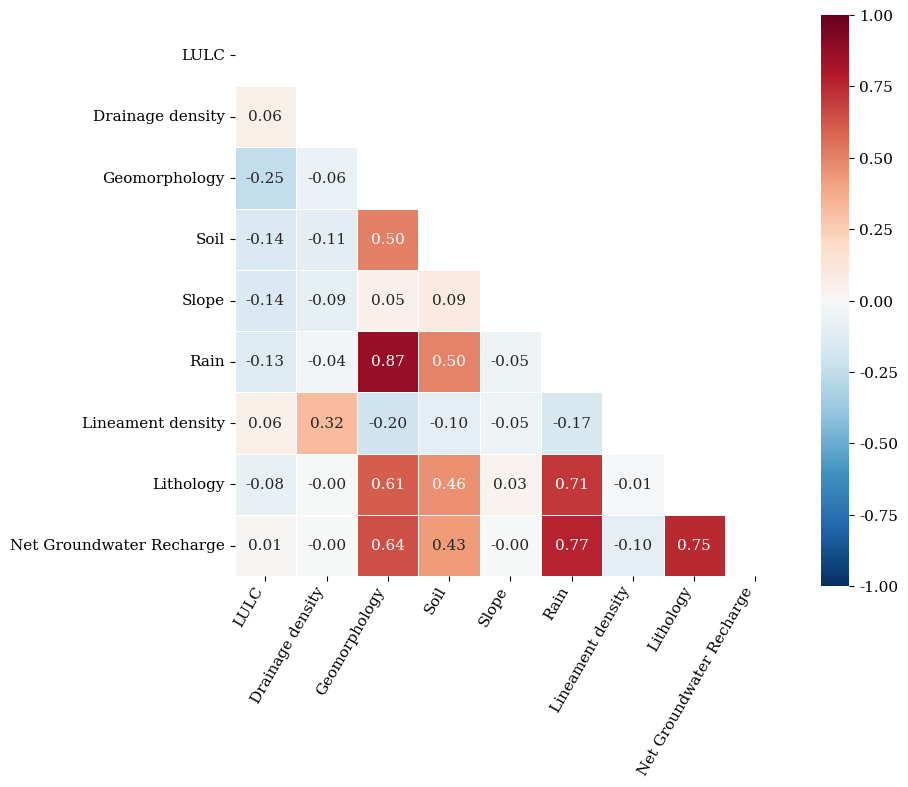

In [4]:
#### HeatMap

# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

# Step 3: Set publication-style fonts
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,

    "font.size": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10
})

# Step 4: Load training dataset
file_path = (
    "/content/drive/My Drive/GWL/r2_complexity/"
    "train219_val99_2obj of GP/train219_dataset.csv"
)

df = pd.read_csv(file_path)

# Step 5: Select the eight hydrogeological variables + target variable
columns = [
    'LULC',
    'Drainage density',
    'Geomorphology',
    'Soil',
    'Slope',
    'Rain',
    'Lineament density',
    'Lithology',
    'Net Groundwater Recharge'
]

data = df[columns]

# Step 6: Calculate Pearson correlation matrix
corr_matrix = data.corr(method='pearson')

# Optional: Print correlation matrix
print(corr_matrix.round(2))

# Step 7: Create mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Step 8: Create heatmap
plt.figure(figsize=(9.5, 8))

ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 11},
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    cbar=True
)

# Step 9: Format variable labels
plt.xticks(
    rotation=60,
    ha='right',
    fontsize=11
)

plt.yticks(
    rotation=0,
    fontsize=11
)

plt.tick_params(
    axis='x',
    pad=2
)

# Step 10: Format color bar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=11)

# Step 11: Adjust layout
plt.tight_layout()

# Step 12: Save as PDF
output_path = (
    "/content/drive/My Drive/GWL/r2_complexity/"
    "train219_val99_2obj of GP/Figure_pdf/"
    "heatmap_train219_with_target.pdf"
)

plt.savefig(
    output_path,
    bbox_inches='tight'
)

# Step 13: Display figure
plt.show()

HV normalization mins (f1 = 1-R², f2 = complexity): [0.38703185 0.        ]
HV normalization maxs (f1 = 1-R², f2 = complexity): [ 2.04396307 42.1       ]
Run 01 HV: 0.928779
Run 02 HV: 0.935086
Run 03 HV: 0.893012
Run 04 HV: 0.965049
Run 05 HV: 0.920920
Run 06 HV: 0.844503
Run 07 HV: 0.898459
Run 08 HV: 0.901268
Run 09 HV: 0.872131
Run 10 HV: 0.934987
Run 11 HV: 0.908820
Run 12 HV: 0.934784
Run 13 HV: 0.913318
Run 14 HV: 0.928463
Run 15 HV: 0.882449
Run 16 HV: 0.901268
Run 17 HV: 0.960663
Run 18 HV: 0.948866
Run 19 HV: 0.962623
Run 20 HV: 0.889911

HV summary (per run):
Mean HV: 0.9162678079737875
Std HV : 0.03182599216630103

Global Pareto HV: 0.9699305494712364


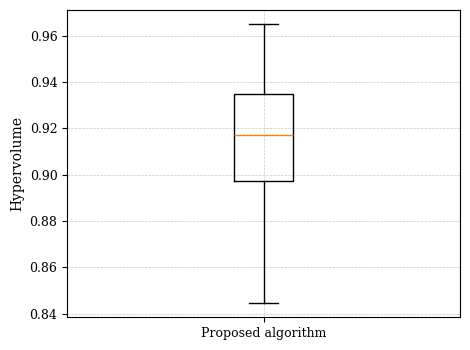

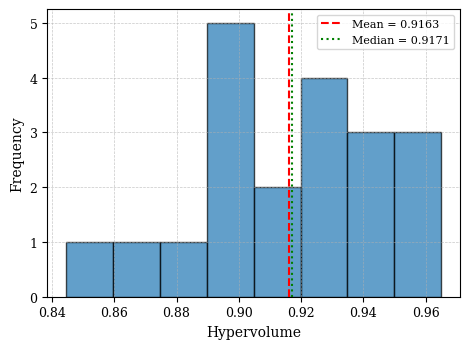

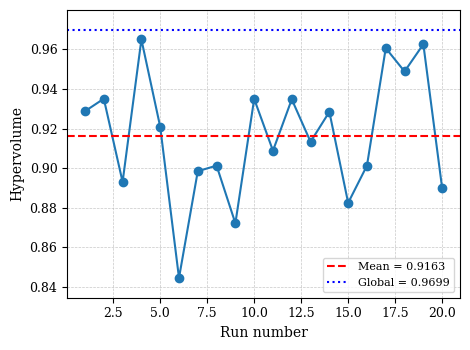

HYPERVOLUME ANALYSIS FOR SYMBOLIC REGRESSION
Number of runs: 20
Mean HV: 0.916268
Std Dev: 0.031826
Median: 0.917119
Min HV: 0.844503
Max HV: 0.965049
Range: 0.120545
Coefficient of Variation: 0.0347
Global Pareto HV: 0.969931
Improvement (Global vs Mean): 5.86%
Runs above mean HV: 10/20


In [ ]:
## HV calculation + plotting together using (1 - R²) and complexity

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ---------------- Font / figure style ----------------
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "axes.unicode_minus": False,
    "font.size": 10,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 8
})

# ---------------- HV helper functions ----------------
def front_to_points_min(front):
    return np.array([[1.0 - ind.r2, ind.complexity] for ind in front], dtype=float)

def unique_points(points, decimals=10):
    pts = np.round(points, decimals=decimals)
    _, idx = np.unique(pts, axis=0, return_index=True)
    return points[np.sort(idx)]

def normalize_points(points, mins, maxs):
    denom = np.where((maxs - mins) == 0.0, 1.0, (maxs - mins))
    return (points - mins) / denom

def hypervolume_2d_min(points_norm, ref=(1.0, 1.0)):
    if len(points_norm) == 0:
        return 0.0

    ref = np.array(ref, dtype=float)
    pts = points_norm[
        (points_norm[:, 0] <= ref[0]) &
        (points_norm[:, 1] <= ref[1])
    ]

    if len(pts) == 0:
        return 0.0

    pts = pts[np.argsort(pts[:, 0])]

    hv = 0.0
    prev_f2 = ref[1]

    for f1, f2 in pts:
        if f2 < prev_f2:
            hv += (ref[0] - f1) * (prev_f2 - f2)
            prev_f2 = f2

    return float(hv)

# ---------------- Build normalization bounds ----------------
pooled_points = []
for pf in all_run_pareto_fronts:
    pooled_points.append(front_to_points_min(pf))

pooled_points = np.vstack(pooled_points) if len(pooled_points) else np.zeros((0, 2))
pooled_points = unique_points(pooled_points, decimals=10)

mins = pooled_points.min(axis=0)
maxs = pooled_points.max(axis=0)

print("HV normalization mins (f1 = 1-R², f2 = complexity):", mins)
print("HV normalization maxs (f1 = 1-R², f2 = complexity):", maxs)

# ---------------- HV per run ----------------
hv_per_run = []

for run_idx, pf in enumerate(all_run_pareto_fronts, start=1):
    pts = front_to_points_min(pf)
    pts = unique_points(pts, decimals=10)
    pts_norm = normalize_points(pts, mins, maxs)
    hv = hypervolume_2d_min(pts_norm, ref=(1.0, 1.0))
    hv_per_run.append(hv)
    print(f"Run {run_idx:02d} HV: {hv:.6f}")

hv_per_run = np.array(hv_per_run)

print("\nHV summary (per run):")
print("Mean HV:", float(hv_per_run.mean()))
print("Std HV :", float(hv_per_run.std(ddof=1)) if len(hv_per_run) > 1 else 0.0)

# ---------------- HV for global Pareto front ----------------
global_pts = front_to_points_min(global_pareto_front)
global_pts = unique_points(global_pts, decimals=10)
global_pts_norm = normalize_points(global_pts, mins, maxs)
hv_global = hypervolume_2d_min(global_pts_norm, ref=(1.0, 1.0))

print("\nGlobal Pareto HV:", hv_global)

# ---------------- Plot HV analysis ----------------

# 1) Box plot
plt.figure(figsize=(4.8, 3.6))

plt.boxplot(hv_per_run)
plt.xticks([1], ["Proposed algorithm"])
#plt.xlabel("Proposed algorithmr")
plt.ylabel("Hypervolume")

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()

plt.savefig(
    "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/Figure_pdf/hv_boxplot.pdf",
    bbox_inches="tight"
)

plt.show()

# 2) Histogram
plt.figure(figsize=(4.8, 3.6))

plt.hist(hv_per_run, bins=8, edgecolor="black", alpha=0.7)

plt.axvline(hv_per_run.mean(), color="red", linestyle="--",
            label=f"Mean = {hv_per_run.mean():.4f}")
plt.axvline(np.median(hv_per_run), color="green", linestyle=":",
            label=f"Median = {np.median(hv_per_run):.4f}")

plt.xlabel("Hypervolume")
plt.ylabel("Frequency")
plt.legend()

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.tight_layout()

# plt.savefig(
#     "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/Figure_pdf/hv_histogram.pdf",
#     bbox_inches="tight"
# )

plt.show()

# 3) Per-run performance
plt.figure(figsize=(4.8, 3.6))

plt.plot(range(1, len(hv_per_run) + 1), hv_per_run, "o-", markersize=6, linewidth=1.5)

plt.axhline(y=hv_per_run.mean(), color="red", linestyle="--",
            label=f"Mean = {hv_per_run.mean():.4f}")
plt.axhline(y=hv_global, color="blue", linestyle=":",
            label=f"Global = {hv_global:.4f}")

plt.xlabel("Run number")
plt.ylabel("Hypervolume")
plt.legend()

plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# dynamic limits
ymin = max(0.0, hv_per_run.min() - 0.01)
ymax = min(1.0, max(hv_per_run.max(), hv_global) + 0.01)
plt.ylim(ymin, ymax)

plt.tight_layout()

plt.savefig(
    "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/Figure_pdf/hv_per_run.pdf",
    bbox_inches="tight"
)

plt.show()

# ---------------- Statistics ----------------
print("=" * 50)
print("HYPERVOLUME ANALYSIS FOR SYMBOLIC REGRESSION")
print("=" * 50)
print(f"Number of runs: {len(hv_per_run)}")
print(f"Mean HV: {hv_per_run.mean():.6f}")
print(f"Std Dev: {hv_per_run.std(ddof=1):.6f}" if len(hv_per_run) > 1 else "Std Dev: 0.000000")
print(f"Median: {np.median(hv_per_run):.6f}")
print(f"Min HV: {hv_per_run.min():.6f}")
print(f"Max HV: {hv_per_run.max():.6f}")
print(f"Range: {hv_per_run.max() - hv_per_run.min():.6f}")
print(f"Coefficient of Variation: {hv_per_run.std(ddof=1)/hv_per_run.mean():.4f}" if len(hv_per_run) > 1 else "Coefficient of Variation: 0.0000")
print(f"Global Pareto HV: {hv_global:.6f}")
print(f"Improvement (Global vs Mean): {(hv_global / hv_per_run.mean() - 1) * 100:.2f}%")
print(f"Runs above mean HV: {sum(hv_per_run > hv_per_run.mean())}/{len(hv_per_run)}")

In [ ]:
## Linear Regression


from sklearn.linear_model import LinearRegression

def build_linear_model_tree(intercept: float, coefs: np.ndarray) -> 'Node':
    """
    Convert: y = intercept + sum_i coefs[i] * x_i
    into a Node tree.
    """
    # start with intercept as constant node
    # We use 'Node' here - make sure your Node class exists!
    expr = Node(str(float(intercept)))

    for i, c in enumerate(coefs):
        # Creates (Weight * x0), (Weight * x1), etc.
        term = Node('*', [Node(str(float(c))), Node(f'x{i}')])
        expr = Node('+', [expr, term])  # Adds it to the total

    return expr


def linear_regression_to_txt(
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list,
    out_txt_path: str,
    var_map: dict,
    precision: int = 6
):
    # 1. Create and train the model
    model = LinearRegression(fit_intercept=True)
    model.fit(X, y)

    # 2. See how accurate it is
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)

    # 3. Build the math tree to calculate "complexity"
    tree = build_linear_model_tree(model.intercept_, model.coef_)
    complexity = tree.weighted_complexity()

    # 4. Turn the tree into a human-readable sentence
    eq_str = tree.to_readable_string(var_map)

    infix_eq_str = prefix_to_infix(eq_str) #prefix to infix

    # 5. Create the text report
    report = []
    report.append("Linear Regression")
    report.append(f"Features ({len(feature_names)}): {feature_names}")
    report.append("")
    # report.append("Expression:")
    # report.append(eq_str)
    # report.append("")

    report.append("Prefix Expression:")
    report.append(eq_str)
    report.append("")
    report.append("Infix Expression:")
    report.append(infix_eq_str)
    report.append("")
    report.append(f"R2: {r2:.{precision}f}")
    report.append(f"Weighted complexity: {complexity:.{precision}f}")

    report_text = "\n".join(report)

    # 6. Print to screen and save to file
    print(report_text)
    with open(out_txt_path, "w", encoding="utf-8") as f:
        f.write(report_text + "\n")

    return {
        "r2": float(r2),
        "weighted_complexity": float(complexity),
        "tree": tree,
        "intercept": float(model.intercept_),
        "coef": model.coef_.astype(float),
        "txt_path": out_txt_path,
    }

In [ ]:
## linear regression expression write in the txt file

linear_txt_path = "/content/drive/My Drive/GWL/r2_complexity/train219_val99_2obj of GP/linear_regression.txt"

lin_result = linear_regression_to_txt(
    X=X,
    y=y,
    feature_names=FEATURE_COLUMNS,
    out_txt_path=linear_txt_path,
    var_map=symbolic_variable_map,
    precision=6
)

Linear Regression
Features (8): ['Soil', 'Slope', 'Rain', 'LULC', 'Lithology', 'Lineament density', 'Geomorphology', 'Drainage density']

Prefix Expression:
+(+(+(+(+(+(+(+(-274.00209750561163, *(2.357361333218397, Soil)), *(2.7172882763595907, Slope)), *(0.14289674061946744, Rain)), *(7.983999647983818, LULC)), *(5.863949598667146, Lithology)), *(-22.21936170952509, Lineament density)), *(-0.2858675032003193, Geomorphology)), *(35.14805983359363, Drainage density))

Infix Expression:
((((((((-274.00209750561163 + (2.357361333218397 * Soil)) + (2.7172882763595907 * Slope)) + (0.14289674061946744 * Rain)) + (7.983999647983818 * LULC)) + (5.863949598667146 * Lithology)) + (-22.21936170952509 * Lineament density)) + (-0.2858675032003193 * Geomorphology)) + (35.14805983359363 * Drainage density))

R2: 0.691465
Weighted complexity: 22.500000
